# Weather Prediction Project: Notebook 1. Data Audit and Problem Framing

### How this notebook fits the final project story

This notebook is the shared opening of the Weather Prediction Project. It merges the original audit with the broader exploratory analysis so the project begins from one common understanding of the data: missingness is structured, rainfall is imbalanced, weather behavior changes by station and climate regime, and temporal order matters for every later model comparison.

The notebook therefore acts as more than an EDA file. It defines the evidence that the later preprocessing and modeling notebooks must respect: no random splitting, no one-size-fits-all missing-value rule, no accuracy-only model ranking, and no feature engineering that ignores geography or seasonality.

### Integrated exploratory analysis

The early audit work was completed across multiple exploratory notebooks and is merged here into one shared project opening. The final audit does not keep separate source notebooks; instead, it carries forward the strongest integrated evidence about imbalance, missingness, climate regimes, station coverage, wind direction, and short-term weather dynamics.

| Integrated audit finding | How it shapes the final workflow |
| --- | --- |
| The target is strongly imbalanced, with the no-rain class dominating the archive. | Later notebooks prioritize recall, F1, ROC-AUC, threshold tuning, and class weighting instead of accuracy alone. |
| Station coverage and sensor availability differ sharply across locations. | Missingness is treated as a data-generating pattern, not just a cleaning nuisance. |
| Climate, NCC, and rainfall-zone views show that Australia cannot be modeled as one homogeneous weather region. | Location, climate regime, rainfall zone, latitude, longitude, and elevation remain important modeling context. |
| Pressure and some stable physical variables are more coherent within climate zones than cloud measurements. | The preprocessing stage keeps variable-specific missing-data logic visible instead of using one universal imputation rule. |
| Wind direction needs circular/vector handling, and month needs cyclic treatment. | Feature engineering avoids ordinal encodings that would create artificial distance between neighboring directions or months. |
| Daily and overnight differences highlight meaningful short-term weather dynamics. | Later feature sets include lag, day-change, overnight-change, humidity, pressure, dew-point, and wind-shift signals. |

<!-- INTEGRATED_AUDIT_MERGE -->
### Integrated audit evidence carried into the final storyline

The merged audit carries forward concrete checks from the additional exploratory analysis, not just a general summary.

| Concrete integrated finding | Why it matters in the final workflow |
| --- | --- |
| The target stays close to a `78 / 22` no-rain / rain split after removing missing labels. | The project must judge models with recall, F1, ROC-AUC, threshold tuning, and class weighting rather than headline accuracy. |
| `Sunshine` is missing in roughly `48%` of rows, `Evaporation` in about `43%`, and `Cloud9am` / `Cloud3pm` in about `38%`. | Missingness cannot be handled by one generic fill rule; it has to stay variable-specific. |
| Climate-zone seasonality differs sharply across the country: tropical regions peak in summer, while alpine and winter-dominant regions peak much later in the year. | `Month` alone is not enough; climate and rainfall-zone context has to stay visible in the feature story. |
| The zone-7 / zone-8 seasonal synchronization check showed that some stable weather structure can be shared across closely related climates. | Zone-aware support is scientifically defensible for selected stable variables, but only where the data really supports it. |
| Cloud relationships were much weaker than pressure relationships in the supplementary audit checks. | Cloud fields are better handled with conservative filling plus missingness indicators than with aggressive zone transfer. |
| Rainfall-zone, elevation, and atmospheric-momentum views all showed that location context and weather change matter together. | The final workflow keeps geography, climate regime, rainfall zone, lag features, day-diff features, and overnight-diff features in the project narrative. |

These checks matter because they explain why the project does not jump directly from raw weather columns to a winner model. The later notebooks inherit this logic: geography matters, temporal order matters, missingness matters, and short-term atmospheric change matters.

![Climate-zone rain frequency by month](../reports/figures/integrated_evidence/integrated_koppenzones_raintomorrow_heatmap.png)

![Rainfall-zone rain frequency](../reports/figures/integrated_evidence/integrated_rainfallzones_raintomorrow.png)

![Daytime atmospheric momentum evidence](../reports/figures/integrated_evidence/integrated_atmospheric_momentum_daydiff.png)

![Overnight atmospheric momentum evidence](../reports/figures/integrated_evidence/integrated_atmospheric_momentum_overnightdiff.png)

<!-- AUDIT_TO_SURFACES -->
### How the audit feeds the unified feature surfaces

The audit is not just a descriptive opening. It determines why the later notebooks need several feature surfaces while still talking about one coherent project.

| Downstream feature surface | Audit evidence that justifies it | Later role in the project |
| --- | --- | --- |
| aligned top-25 feature table | The audit showed that a compact set of strong afternoon moisture, pressure, sunshine, rain-history, and location signals already carries meaningful predictive structure. | Supports the interpretable and like-for-like baseline comparison used for Logistic Regression, Random Forest, and aligned XGBoost. |
| broader all-feature weather table with climate context | The audit showed that climate regime, rainfall zone, station context, and structured missingness all matter and should not be collapsed away too early. | Supports the richer boosted-tree, calibration, and all-feature challenger studies. |
| 68-feature hybrid-plus-core winner representation | The audit showed that missingness indicators, day-change features, lagged weather signals, and climate-aware context all carry real forecasting value together. | Becomes the canonical final CatBoost driver set and the common 68-driver base for the locked winner package. |
| 68-feature scaled high-dimensional hybrid representation | The audit showed that the same weather story should remain visible even when models need standardized magnitudes. | Supports the saved dense-neural benchmark while preserving the same core weather drivers. |
| rolling 68-driver sequence views | The audit showed that daily and overnight changes matter, which naturally motivates ordered temporal windows rather than one-row snapshots alone. | Supports the LSTM, GRU, attention, and CNN sequence challengers. |

This is the bridge from notebook 1 to the rest of the workflow. The project keeps one canonical meteorological language, but it allows that language to be expressed through different valid model surfaces when the family requires it.

## 1. Import Libraries

This section loads the analysis and visualization tools used throughout the audit. Keeping the imports explicit makes the notebook easier to reproduce and shows which packages support the statistical and graphical decisions later on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")


In [2]:
# Chart export setup 

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CHARTS_DIR = PROJECT_ROOT / "reports" / "figures"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Charts will be saved to: {CHARTS_DIR}")


Charts will be saved to: C:\Users\user 1\Desktop\feb26_bds_int_weather\reports\figures


## 2. Dataset Loading

This section brings the raw weather dataset into the notebook and verifies that the project is starting from the original source file. The goal is to establish a trustworthy base before any exploration, statistics, or feature reasoning begins.

In [3]:
from pathlib import Path

Path("../data/raw").mkdir(parents=True, exist_ok=True)
Path("../data/preprocessed").mkdir(parents=True, exist_ok=True)

print("Folders created")


Folders created


In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "weatherAUS.csv"

print("Loading from:", DATA_PATH.resolve())
print("Exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

df.head()


Loading from: C:\Users\user 1\Desktop\feb26_bds_int_weather\data\raw\weatherAUS.csv
Exists: True


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


The first five rows give an immediate overview of the dataset:
- one date,
- one location,
- several numerical weather measurements,
- and two Yes/No rain columns.

For this project, the main target is **`RainTomorrow`**. We still inspect the full table because some columns may later be useful predictors, but all target-specific analysis will now centre on tomorrow's rain only.

## 3. Dataset Overview

This first overview answers the basic scope questions: how many observations we have, how many columns are available, and what one row represents. It helps frame the rest of the audit around the actual scale of the prediction problem.

In [5]:
df.shape


(145460, 23)

**Interpretation:** The dataset has roughly **145,460 rows and 23 columns**. Each row is one day-location observation. 23 columns is a manageable number and enough to capture diverse meteorological conditions.

In [6]:
df.columns


Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

**Column breakdown:** The 23 columns fall into four groups:

- **Identifiers**: `Date`, `Location`
- **Temperature**: `MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`
- **Rain / humidity**: `Rainfall`, `Humidity9am`, `Humidity3pm`, `RainToday`, `RainTomorrow`
- **Wind**: `WindGustDir`, `WindGustSpeed`, `WindDir9am`, `WindDir3pm`, `WindSpeed9am`, `WindSpeed3pm`
- **Atmosphere / other**: `Pressure9am`, `Pressure3pm`, `Cloud9am`, `Cloud3pm`, `Sunshine`, `Evaporation`

The `9am` and `3pm` suffixes indicate measurements taken at those specific times of day.

## 4. Data Types and Structure

This section checks whether each variable is stored in a form that matches its meaning. Understanding the mix of dates, categorical variables, and numeric measurements is essential before moving into correlation analysis, visualization, or preprocessing design.

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Interpretation:**

- Most measurement columns are `float64` (continuous numbers), which is expected for weather readings.
- `Date` is loaded as `object` (string) and we will convert it to a datetime format later in the notebook.
- `Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `RainTomorrow` are `object` (categorical text) and these would need encoding later when we move to modeling.
- Several columns already show fewer than 145,460 non-null values, confirming missing data. The worst offenders in our case (Sunshine, Evaporation, Cloud columns) are visible here and they will be analysed in detail in Section 6.

## 5. Summary Statistics of the DataFrame

This section gives a first numerical reading of the weather variables: their ranges, centres, spread, and possible outliers. It is where we begin translating raw columns into early modeling intuition.

In [8]:
df.describe() 


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


**Key observations from the summary statistics:**

- **Rainfall** has a mean of ~2mm but a max of 371mm: this extreme imbalance confirms that most days are dry but storms produce enormous values. The median (50th percentile) is likely 0mm. This is important later because median imputation will be safer than mean imputation.
- **WindGustSpeed** ranges from 6 to 135 km/h with a mean around 40 km/h: a wide spread suggesting the variable will be challenging to regress accurately.
- **Temperature** variables (MinTemp, MaxTemp, Temp9am, Temp3pm) show reasonable ranges (-8°C to 48°C) consistent with Australia's diverse climates.
- **Humidity** ranges from 0 to 100% as expected. The 75th percentile of Humidity3pm is around 65%, meaning most afternoons are relatively dry.
- **Pressure** sits in a narrow band (~980–1040 hPa), which is normal for atmospheric pressure.
- **Sunshine** (hours of sunlight) ranges 0–14.5 hours, with a high proportion of missing values visible in the count row.

## 6. Dataset Limitations

This section identifies the main weaknesses of the raw dataset before any model is built. Missingness, uneven station coverage, temporal structure, and class imbalance all shape what a sensible preprocessing strategy should look like.

In [9]:
# Missing values report by column
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_%": missing_percent
}).sort_values("Missing_%", ascending=False)

print("Missing values by column:")
print(missing_report.to_string())


Missing values by column:
               Missing_Count  Missing_%
Sunshine               69835      48.01
Evaporation            62790      43.17
Cloud3pm               59358      40.81
Cloud9am               55888      38.42
Pressure9am            15065      10.36
Pressure3pm            15028      10.33
WindDir9am             10566       7.26
WindGustDir            10326       7.10
WindGustSpeed          10263       7.06
Humidity3pm             4507       3.10
WindDir3pm              4228       2.91
Temp3pm                 3609       2.48
RainTomorrow            3267       2.25
Rainfall                3261       2.24
RainToday               3261       2.24
WindSpeed3pm            3062       2.11
Humidity9am             2654       1.82
WindSpeed9am            1767       1.21
Temp9am                 1767       1.21
MinTemp                 1485       1.02
MaxTemp                 1261       0.87
Date                       0       0.00
Location                   0       0.00


Columns with missing values only:
               Missing_Count  Missing_%
Sunshine               69835      48.01
Evaporation            62790      43.17
Cloud3pm               59358      40.81
Cloud9am               55888      38.42
Pressure9am            15065      10.36
Pressure3pm            15028      10.33
WindDir9am             10566       7.26
WindGustDir            10326       7.10
WindGustSpeed          10263       7.06
Humidity3pm             4507       3.10
WindDir3pm              4228       2.91
Temp3pm                 3609       2.48
RainTomorrow            3267       2.25
Rainfall                3261       2.24
RainToday               3261       2.24
WindSpeed3pm            3062       2.11
Humidity9am             2654       1.82
WindSpeed9am            1767       1.21
Temp9am                 1767       1.21
MinTemp                 1485       1.02
MaxTemp                 1261       0.87


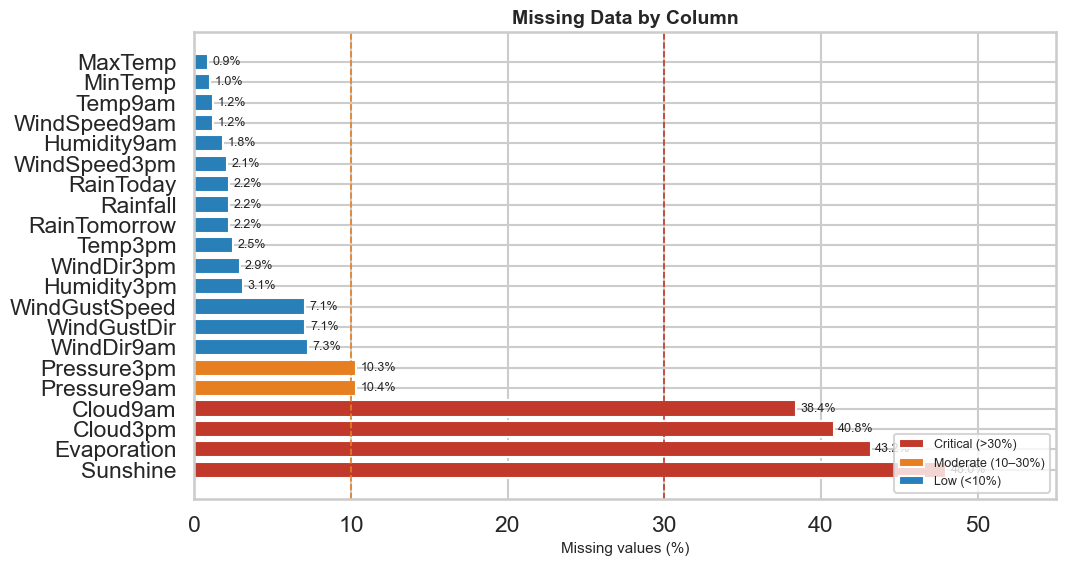

In [10]:
# Keep only columns that actually have missing values
missing_only = missing_report[missing_report["Missing_Count"] > 0].copy()

print("Columns with missing values only:")
print(missing_only.to_string())

# Static figure

missing_only_sorted = missing_only.sort_values("Missing_%", ascending=False)

colors = []
for v in missing_only_sorted["Missing_%"]:
    if v >= 30:
        colors.append("#C0392B")   # red — Critical
    elif v >= 10:
        colors.append("#E67E22")   # orange — Moderate
    else:
        colors.append("#2980B9")   # blue — Low

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(missing_only_sorted["Column"] if "Column" in missing_only_sorted.columns
               else missing_only_sorted.index,
               missing_only_sorted["Missing_%"],
               color=colors)

# Threshold lines
ax.axvline(x=10, color="#E67E22", linestyle="--", linewidth=1.2, label="Moderate (10–30%)")
ax.axvline(x=30, color="#C0392B", linestyle="--", linewidth=1.2, label="Critical (>30%)")

# Value labels
for bar, val in zip(bars, missing_only_sorted["Missing_%"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C0392B", label="Critical (>30%)"),
    Patch(facecolor="#E67E22", label="Moderate (10–30%)"),
    Patch(facecolor="#2980B9", label="Low (<10%)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title("Missing Data by Column", fontsize=14, fontweight="bold")
ax.set_xlabel("Missing values (%)", fontsize=11)
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_02_missing_bar.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation of missing values figure:**

| Severity | Columns | Why this matters |
|----------|---------|------------------|
| Very high (>40%) | `Sunshine` (~48%), `Evaporation` (~43%) | Most missing; yet both are strong rain predictors |
| High (30–40%) | `Cloud9am`, `Cloud3pm` (~38%) | Cloud cover is directly linked to rain |
| Moderate (5–20%) | `Pressure9am/3pm`, `WindDir` columns | Less critical but still significant |
| Low (<5%) | Temperature, humidity, wind speed columns | Safe to impute with minimal risk |

The most problematic columns are Sunshine and Cloud cover: they are missing the most and are among the strongest rain predictors. Simply deleting rows with missing values would eliminate roughly half the dataset. We therefore suggest to use **median imputation** for numerical columns and **mode imputation** for categorical ones, which preserves all rows.

### 6.1 Missing Values by Row

Column-level missingness tells us **which variables** are incomplete.  
Row-level missingness tells us **which observations** are incomplete.

This matters because some rows may have only 1 missing value, while others may be missing many measurements at the same time. Those heavily incomplete rows can become a problem later if we try to model without checking them first.

In [11]:
# Missing values report by row
row_missing_count = df.isna().sum(axis=1)

print("Row-level missing value summary:")
print(row_missing_count.describe())

row_missing_report = row_missing_count.value_counts().sort_index().reset_index()
row_missing_report.columns = ["Missing_Values_in_Row", "Number_of_Rows"]
row_missing_report["Row_%"] = (row_missing_report["Number_of_Rows"] / len(df) * 100).round(2)

print("\n---------------------------------------------")
print(row_missing_report.to_string(index=False))


Row-level missing value summary:
count    145460.000000
mean          2.359742
std           2.709323
min           0.000000
25%           0.000000
50%           2.000000
75%           4.000000
max          21.000000
dtype: float64

---------------------------------------------
 Missing_Values_in_Row  Number_of_Rows  Row_%
                     0           56420  38.79
                     1           10909   7.50
                     2           18346  12.61
                     3            9782   6.72
                     4           28675  19.71
                     5            4141   2.85
                     6           10229   7.03
                     7            2277   1.57
                     8            1072   0.74
                     9             492   0.34
                    10             328   0.23
                    11             719   0.49
                    12             781   0.54
                    13             617   0.42
                    14         

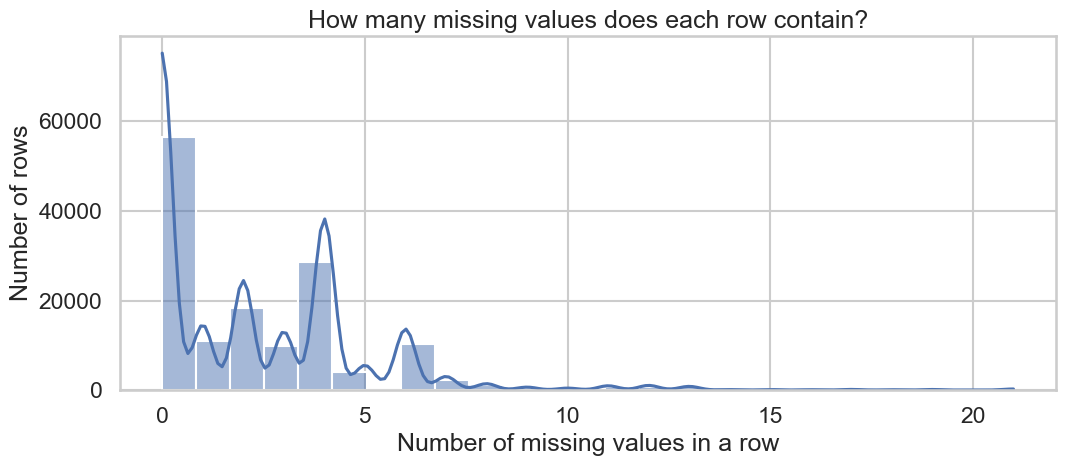

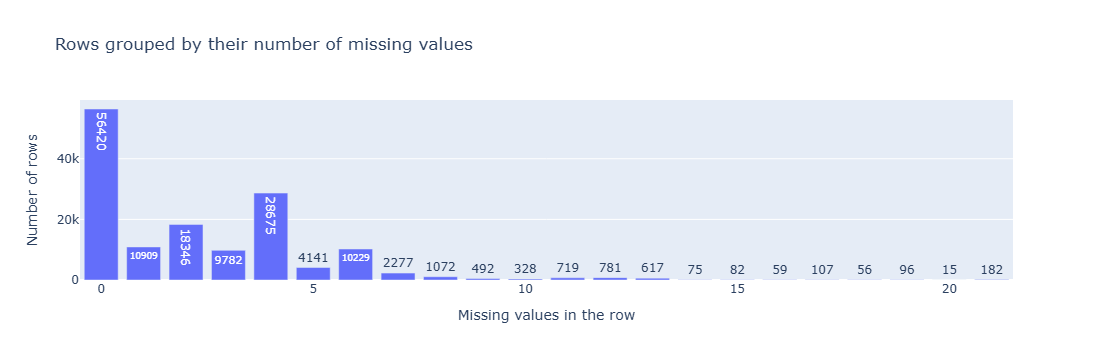

Rows with at least 5 missing values: 21328 (14.66%)
Rows with at least 8 missing values: 4681 (3.22%)
Rows with at least 10 missing values: 3117 (2.14%)


In [12]:
# row-level missing values
plt.figure(figsize=(11, 5))
sns.histplot(row_missing_count, bins=25, kde=True)
plt.title("How many missing values does each row contain?")
plt.xlabel("Number of missing values in a row")
plt.ylabel("Number of rows")
plt.tight_layout()

plt.savefig(os.path.join(CHARTS_DIR, "fig_01b_missing_per_row_hist.png"), dpi=150, bbox_inches="tight")
plt.show()

# Interactive version
row_missing_plot = row_missing_report.copy()
fig = px.bar(
    row_missing_plot,
    x="Missing_Values_in_Row",
    y="Number_of_Rows",
    title="Rows grouped by their number of missing values",
    text="Number_of_Rows"
)
fig.update_layout(xaxis_title="Missing values in the row", yaxis_title="Number of rows")
fig.show()


# Simple reporting for rows with many missing values
for limit in [5, 8, 10]:
    count_rows = (row_missing_count >= limit).sum()
    percent_rows = round(count_rows / len(df) * 100, 2)
    print(f"Rows with at least {limit} missing values: {count_rows} ({percent_rows}%)")


**Interpretation of row missingness:**  
- If most rows have **0 to 2 missing values**, the dataset is broadly usable and later imputation is realistic.
- If a visible tail of rows has **many missing variables at once**, those rows need special attention because they may reflect station outages, transmission failures, or incomplete observation days.
- At the statistical phase, we **report these rows but do not delete them yet**. Deletion belongs to preprocessing, after we decide the exact rules.

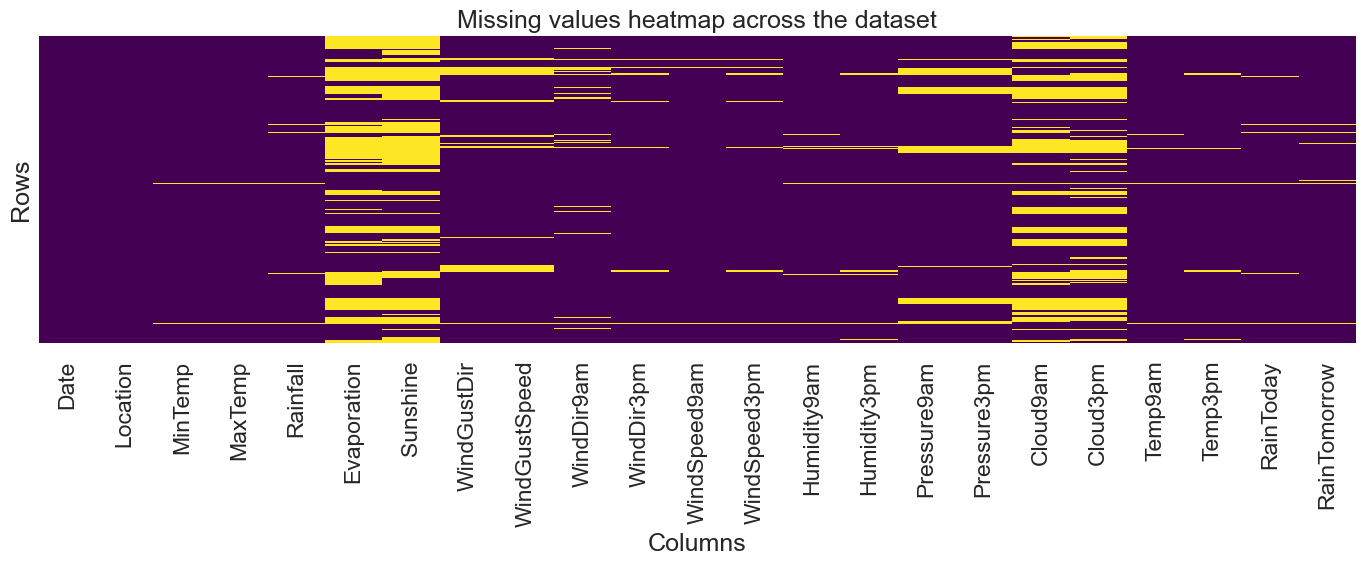

In [13]:
# Visualizing missing data with a cleaner heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values heatmap across the dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()

plt.savefig(os.path.join(CHARTS_DIR, "fig_01_missing_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


**Heatmap interpretation:** Each vertical stripe of yellow in the heatmap represents a column with many missing values. The pattern shows that missingness is not random and certain columns are systematically absent across large blocks of rows. This is consistent with the hypothesis that specific weather stations simply did not have certain instruments. This is called **MNAR (Missing Not At Random)**, which is the most difficult type to handle because the absence itself can carry information.

## 7. Missingness Mechanisms: Investigating Systematic Patterns

Missing data is not always random. When sensors consistently fail under specific conditions and/or when certain weather stations simply never had particular instruments, the missingness, thus, follows a pattern (**MNAR: Missing Not At Random**).

Understanding *why* data is missing matters because:
- If a column is missing precisely when its value would be extreme (for example: Sunshine=0 on stormy days), then filling it with the median can underestimate the true value.

- If whole stations are missing entire columns, that is most probably an equipment issue, not a weather issue.

We investigate three hypotheses:

1. **Location hypothesis**: certain stations never recorded certain variables (equipment gap)
2. **Seasonal hypothesis**: certain variables go missing more in specific months (e.g. sensor failure in winter, or daylight-dependent instruments)
3. **Weather-condition hypothesis**: missingness correlates with the weather itself (e.g. Sunshine missing on rainy days, Evaporation missing in cold/wet conditions)

### Hypothesis 1: Location: Are Entire Stations Missing Certain Columns?


Missing % of Sunshine by location:
Location
Albury              100.00
GoldCoast           100.00
BadgerysCreek       100.00
Bendigo             100.00
Ballarat            100.00
Katherine           100.00
Wollongong          100.00
Walpole             100.00
Uluru               100.00
Richmond            100.00
SalmonGums          100.00
Penrith             100.00
NorahHead           100.00
Nhil                100.00
MountGinini         100.00
Newcastle           100.00
Launceston          100.00
Tuggeranong         100.00
Witchcliffe         100.00
Cobar                81.72
Canberra             55.73
Williamtown          54.97
CoffsHarbour         50.35
Adelaide             44.60
Sale                 39.58
Woomera              33.30
Moree                31.70
AliceSprings         17.11
Albany               17.11
Cairns               15.66
Portland             14.72
Dartmoor             14.72
NorfolkIsland        14.59
MountGambier         14.57
WaggaWagga           14.42
Townsville

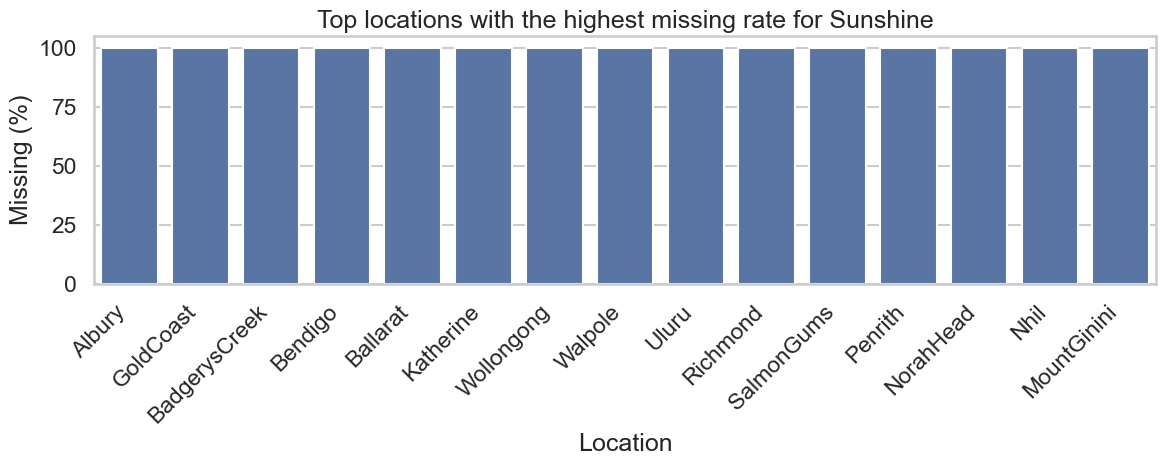


Missing % of Evaporation by location:
Location
Albury              100.00
Ballarat            100.00
BadgerysCreek       100.00
GoldCoast           100.00
PearceRAAF          100.00
Witchcliffe         100.00
Wollongong          100.00
Walpole             100.00
Uluru               100.00
SalmonGums          100.00
Tuggeranong         100.00
Penrith             100.00
MountGinini         100.00
Nhil                100.00
NorahHead           100.00
Newcastle           100.00
Launceston           95.36
Bendigo              61.02
Canberra             46.68
Adelaide             46.63
Richmond             46.03
CoffsHarbour         40.68
Sale                 39.05
Williamtown          35.33
Moree                23.83
Woomera              14.59
Dartmoor             13.59
Portland             13.59
MountGambier         13.49
Cairns               12.17
Cobar                11.40
Albany                9.54
NorfolkIsland         7.78
AliceSprings          7.07
Katherine             5.89
WaggaWa

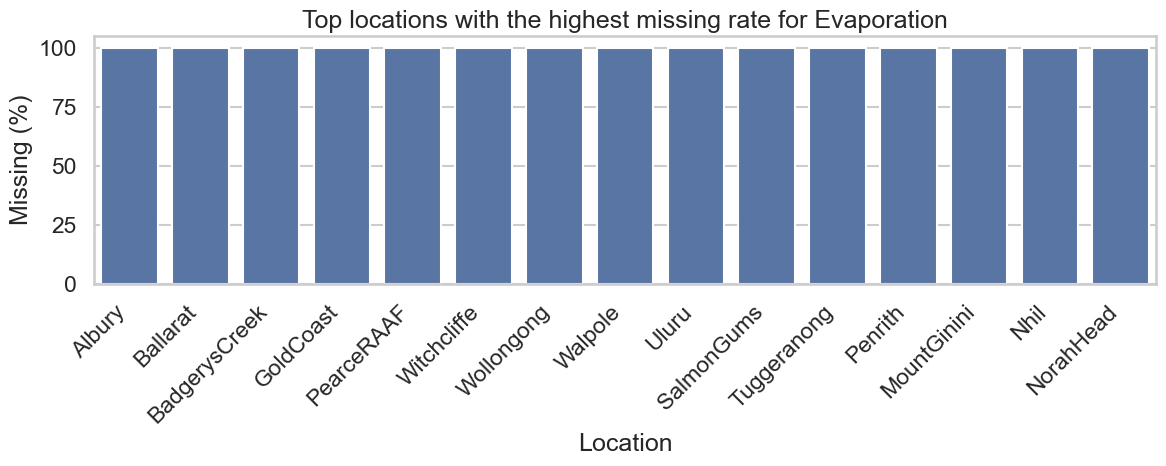


Missing % of Cloud9am by location:
Location
Adelaide            100.00
BadgerysCreek       100.00
Dartmoor            100.00
GoldCoast           100.00
Walpole             100.00
Nhil                100.00
NorahHead           100.00
Penrith             100.00
MountGinini         100.00
SalmonGums          100.00
Tuggeranong         100.00
Witchcliffe         100.00
Richmond             79.89
Uluru                77.95
Launceston           76.15
Albury               57.60
Wollongong           55.76
Hobart               36.42
PearceRAAF           34.66
Melbourne            32.38
Bendigo              31.84
Canberra             31.20
CoffsHarbour         27.02
Williamtown          20.01
Ballarat             17.96
Moree                17.88
Sydney               16.99
Portland             13.69
Cobar                12.63
Woomera              12.43
Sale                 11.90
AliceSprings         10.99
Newcastle             7.93
WaggaWagga            7.41
Cairns                6.81
Townsville

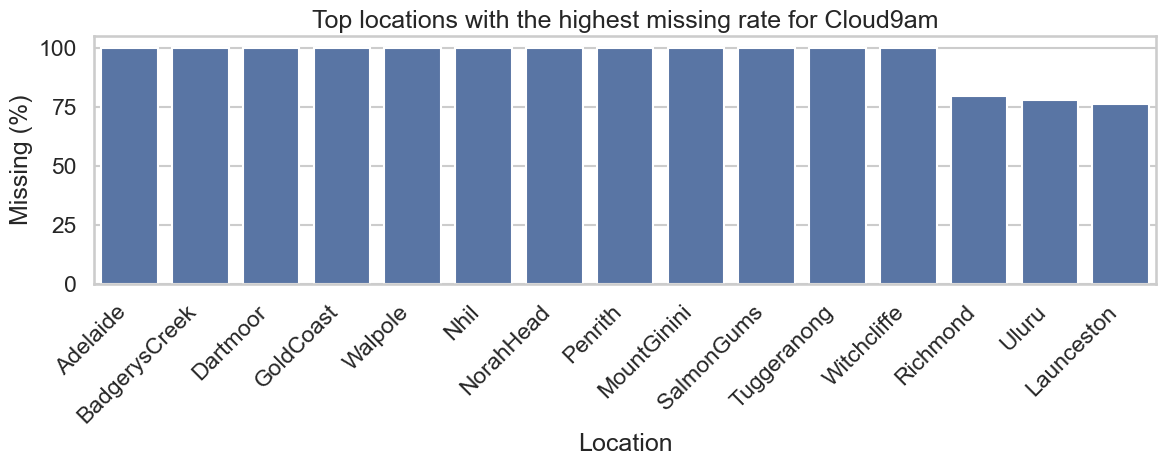


Missing % of Cloud3pm by location:
Location
Adelaide            100.00
BadgerysCreek       100.00
Dartmoor            100.00
GoldCoast           100.00
Walpole             100.00
Nhil                100.00
NorahHead           100.00
Penrith             100.00
MountGinini         100.00
SalmonGums          100.00
Tuggeranong         100.00
Witchcliffe         100.00
Richmond             80.66
Launceston           75.59
Uluru                73.57
Wollongong           53.39
Albury               53.06
Katherine            45.88
PearceRAAF           37.49
Canberra             36.76
Hobart               36.58
Melbourne            34.64
Ballarat             34.47
Newcastle            30.70
CoffsHarbour         25.86
Nuriootpa            25.56
Bendigo              25.39
Albany               23.39
Woomera              21.90
Williamtown          21.57
Portland             17.25
Sydney               16.84
Moree                13.43
Sale                 13.03
AliceSprings         11.88
Cobar     

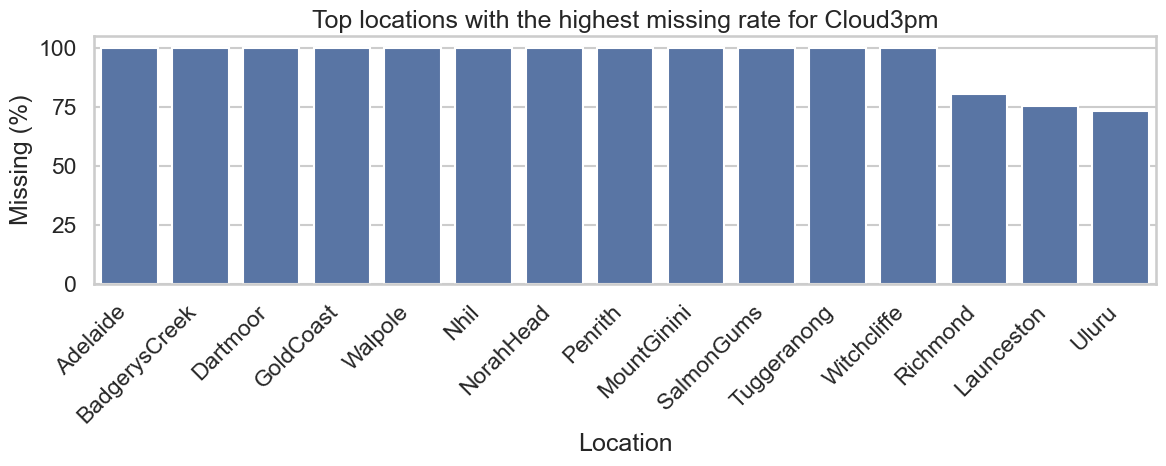

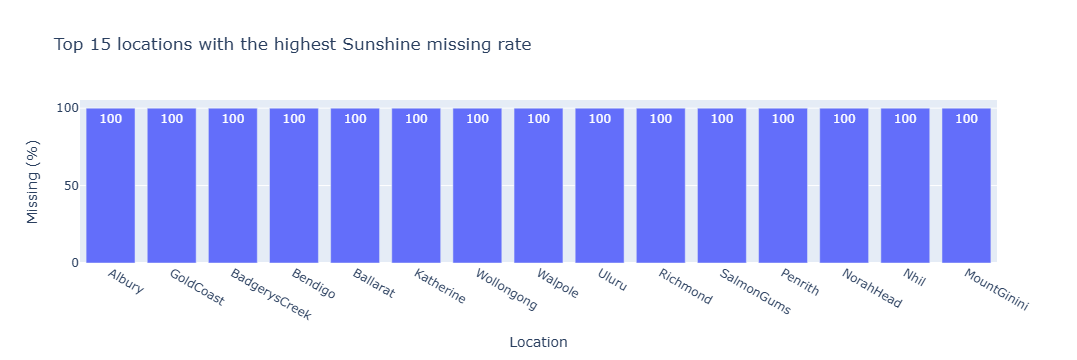

In [14]:
# Missing percentage by location for the main high-missing columns
high_missing_cols = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]

for col in high_missing_cols:
    print(f"\nMissing % of {col} by location:")
    missing_by_location = df.groupby("Location")[col].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False).round(2)
    print(missing_by_location.to_string())

    top_locations = missing_by_location.head(15).reset_index()
    top_locations.columns = ["Location", "Missing_%"]

    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_locations, x="Location", y="Missing_%")
    plt.title(f"Top locations with the highest missing rate for {col}")
    plt.xlabel("Location")
    plt.ylabel("Missing (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, f"fig_missing_by_location_{col.lower()}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

# Interactive view for one important variable
sunshine_by_location = df.groupby("Location")["Sunshine"].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False).head(15).reset_index()
sunshine_by_location.columns = ["Location", "Missing_%"]

fig = px.bar(
    sunshine_by_location,
    x="Location",
    y="Missing_%",
    title="Top 15 locations with the highest Sunshine missing rate",
    text="Missing_%"
)
fig.update_layout(xaxis_title="Location", yaxis_title="Missing (%)")
fig.show()


In [15]:
# Which locations have a column fully missing?
for col in high_missing_cols:
    missing_by_location = df.groupby("Location")[col].apply(lambda x: x.isna().mean() * 100)
    full_missing_locations = missing_by_location[missing_by_location == 100].index.tolist()

    print(f"{col}: {len(full_missing_locations)} locations with 100% missing values")
    print(full_missing_locations)
    print()


Sunshine: 19 locations with 100% missing values
['Albury', 'BadgerysCreek', 'Ballarat', 'Bendigo', 'GoldCoast', 'Katherine', 'Launceston', 'MountGinini', 'Newcastle', 'Nhil', 'NorahHead', 'Penrith', 'Richmond', 'SalmonGums', 'Tuggeranong', 'Uluru', 'Walpole', 'Witchcliffe', 'Wollongong']

Evaporation: 16 locations with 100% missing values
['Albury', 'BadgerysCreek', 'Ballarat', 'GoldCoast', 'MountGinini', 'Newcastle', 'Nhil', 'NorahHead', 'PearceRAAF', 'Penrith', 'SalmonGums', 'Tuggeranong', 'Uluru', 'Walpole', 'Witchcliffe', 'Wollongong']

Cloud9am: 12 locations with 100% missing values
['Adelaide', 'BadgerysCreek', 'Dartmoor', 'GoldCoast', 'MountGinini', 'Nhil', 'NorahHead', 'Penrith', 'SalmonGums', 'Tuggeranong', 'Walpole', 'Witchcliffe']

Cloud3pm: 12 locations with 100% missing values
['Adelaide', 'BadgerysCreek', 'Dartmoor', 'GoldCoast', 'MountGinini', 'Nhil', 'NorahHead', 'Penrith', 'SalmonGums', 'Tuggeranong', 'Walpole', 'Witchcliffe']



**Interpretation of the Location hypothesis:**

The bars reaching 100% (crimson) reveal stations where a column is **entirely absent** which means that the instrument was simply never installed at that location. This is a pure **equipment gap**, not weather-related missingness.

Key findings:
- `Sunshine` is 100% missing at multiple inland and remote stations. Sunshine recorders were not deployed everywhere.
- `Evaporation` shows a similar pattern and evaporimeters are not available at all stations.
- `Cloud9am` and `Cloud3pm` are missing at some stations but partially missing at others, suggesting a mix of equipment gaps and occasional recording failures.

**Conclusion:** A large fraction of missing data in these columns is purely structural and it has nothing to do with the weather that day. This confirms that the data is missing because of *where* the station is, not *what* the weather was.

### Hypothesis 2: Seasonal: Does Missingness Vary by Month?


Missing % of Sunshine by month:
 Month  Missing_%
     1      47.36
     2      47.17
     3      47.03
     4      48.53
     5      50.46
     6      49.83
     7      46.82
     8      47.58
     9      47.46
    10      47.46
    11      47.27
    12      48.92


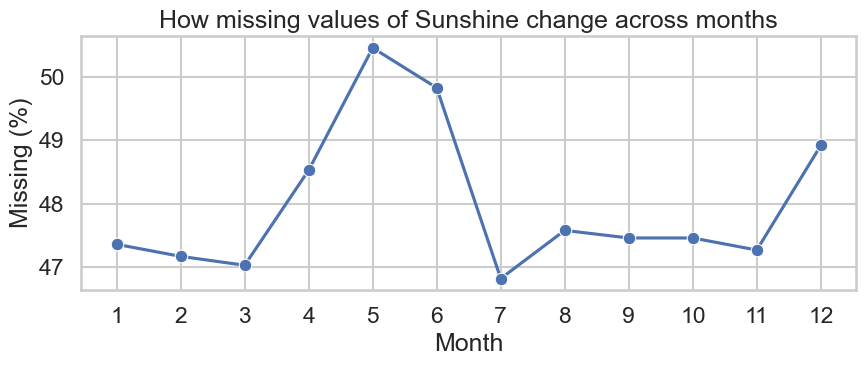


Missing % of Evaporation by month:
 Month  Missing_%
     1      43.62
     2      43.19
     3      43.07
     4      43.65
     5      44.61
     6      44.93
     7      41.16
     8      42.38
     9      42.10
    10      42.69
    11      42.39
    12      43.95


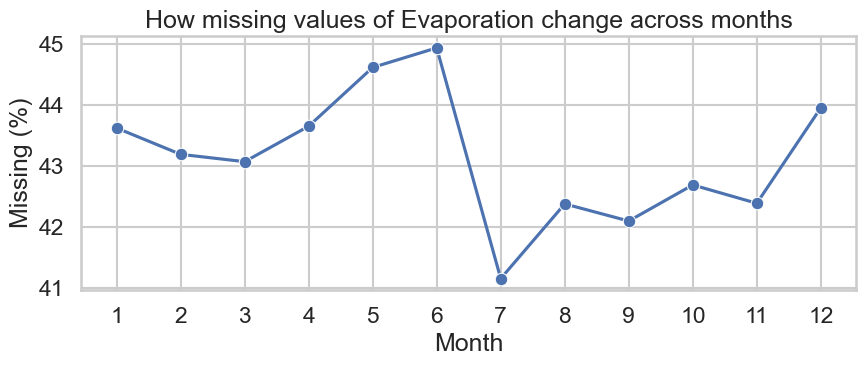


Missing % of Cloud9am by month:
 Month  Missing_%
     1      39.93
     2      38.80
     3      38.82
     4      38.85
     5      38.82
     6      37.20
     7      36.02
     8      37.13
     9      37.95
    10      39.18
    11      38.46
    12      39.86


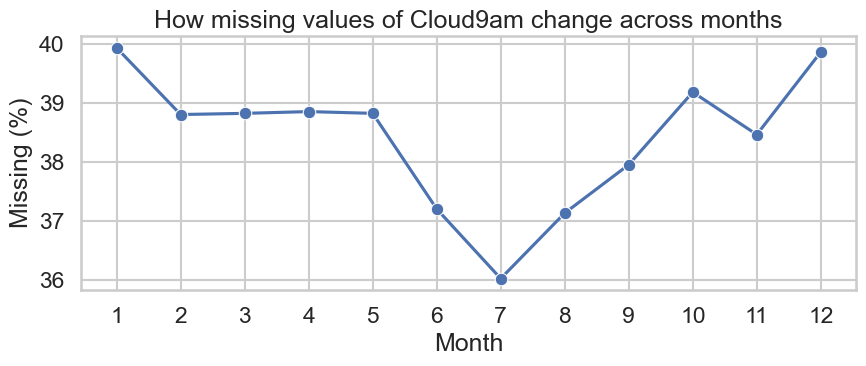


Missing % of Cloud3pm by month:
 Month  Missing_%
     1      43.06
     2      42.08
     3      41.03
     4      40.68
     5      41.31
     6      39.90
     7      37.10
     8      38.85
     9      39.66
    10      41.66
    11      41.65
    12      42.70


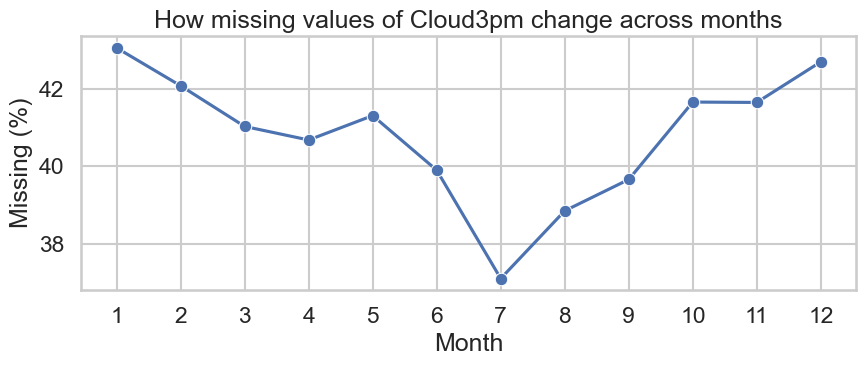

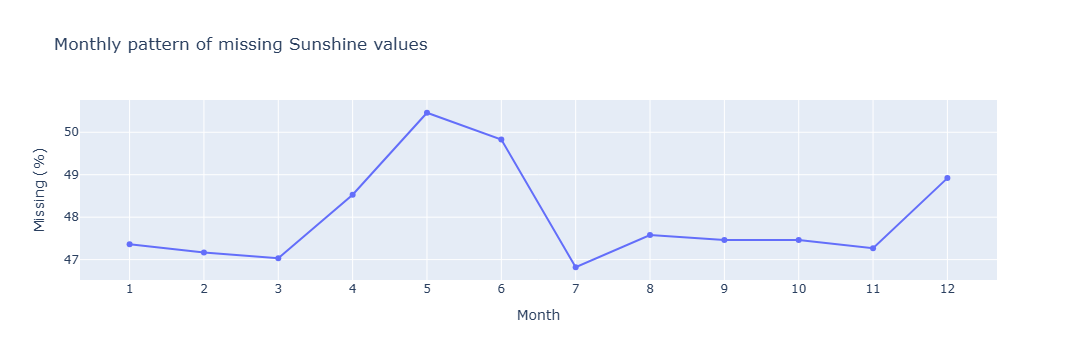

In [16]:
# Missing percentage by month
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

for col in high_missing_cols:
    missing_by_month = df.groupby("Month")[col].apply(lambda x: x.isna().mean() * 100).round(2).reset_index()
    missing_by_month.columns = ["Month", "Missing_%"]

    print(f"\nMissing % of {col} by month:")
    print(missing_by_month.to_string(index=False))

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=missing_by_month, x="Month", y="Missing_%", marker="o")
    plt.title(f"How missing values of {col} change across months")
    plt.xlabel("Month")
    plt.ylabel("Missing (%)")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, f"fig_missing_by_month_{col.lower()}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

# Interactive monthly figure for Sunshine
sunshine_by_month = df.groupby("Month")["Sunshine"].apply(lambda x: x.isna().mean() * 100).round(2).reset_index()
sunshine_by_month.columns = ["Month", "Missing_%"]

fig = px.line(
    sunshine_by_month,
    x="Month",
    y="Missing_%",
    markers=True,
    title="Monthly pattern of missing Sunshine values"
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1), yaxis_title="Missing (%)")
fig.show()


**Interpretation of the seasonal hypothesis:**

For stations that *do* have the instruments, we now check whether missingness peaks in certain months. If the bars are flat across all months, missingness is random within those stations. If there is a seasonal peak, something systematic is causing failures at specific times of year.

- **Flat pattern** → missingness is random / administrative (sensor maintenance, data transmission issues) with no seasonal driver.
- **Winter peak** → could indicate frost or ice affecting instruments (e.g. evaporation pans freeze, sunshine recorders fog up).
- **Summer peak** → heat could cause sensor failures or calibration drift.

### Hypothesis 3: Weather Conditions: Is Missingness Correlated With the Weather Itself?

In [17]:
# Compare simple weather conditions when data is present vs missing
checks = [
    ("Sunshine", "Humidity3pm"),
    ("Evaporation", "MaxTemp"),
    ("Cloud9am", "Rainfall"),
    ("Cloud3pm", "Humidity3pm")
]

results = []

for missing_col, compare_col in checks:
    present_mean = df.loc[df[missing_col].notna(), compare_col].mean()
    missing_mean = df.loc[df[missing_col].isna(), compare_col].mean()

    results.append({
        "Column_with_Missing": missing_col,
        "Compared_with": compare_col,
        "Mean_when_present": round(present_mean, 2),
        "Mean_when_missing": round(missing_mean, 2),
        "Difference": round(missing_mean - present_mean, 2)
    })

missing_pattern_report = pd.DataFrame(results)
print(missing_pattern_report.to_string(index=False))


Column_with_Missing Compared_with  Mean_when_present  Mean_when_missing  Difference
           Sunshine   Humidity3pm              50.39              52.83        2.44
        Evaporation       MaxTemp              23.88              22.35       -1.53
           Cloud9am      Rainfall               2.59               1.97       -0.62
           Cloud3pm   Humidity3pm              51.62              51.41       -0.21


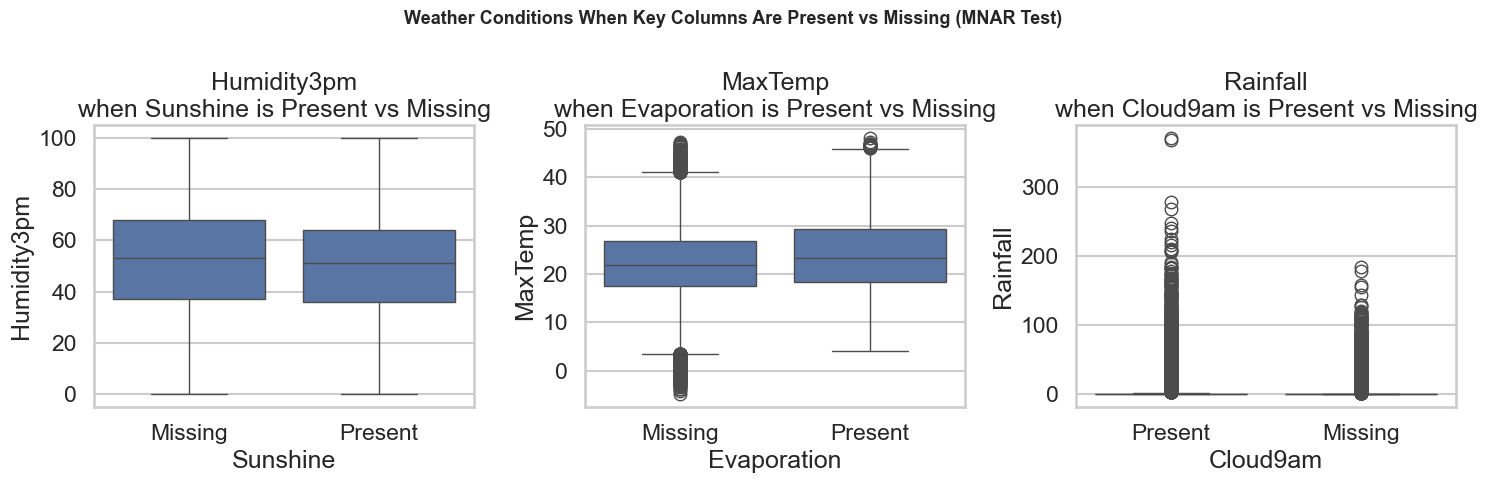

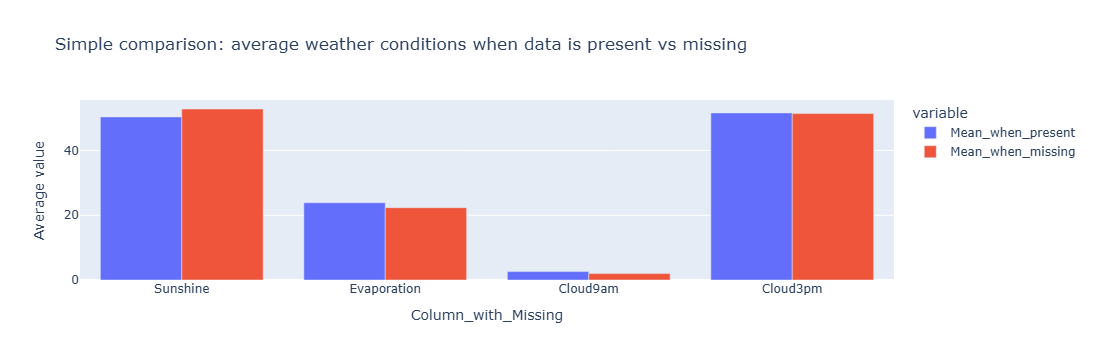

In [18]:
# boxplots: present vs missing
# Merged into one figure so it can be saved

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    data=df,
    x=df["Sunshine"].isna().map({False: "Present", True: "Missing"}),
    y="Humidity3pm", ax=axes[0]
)
axes[0].set_title("Humidity3pm\nwhen Sunshine is Present vs Missing")
axes[0].set_xlabel("Sunshine")

sns.boxplot(
    data=df,
    x=df["Evaporation"].isna().map({False: "Present", True: "Missing"}),
    y="MaxTemp", ax=axes[1]
)
axes[1].set_title("MaxTemp\nwhen Evaporation is Present vs Missing")
axes[1].set_xlabel("Evaporation")

sns.boxplot(
    data=df,
    x=df["Cloud9am"].isna().map({False: "Present", True: "Missing"}),
    y="Rainfall", ax=axes[2]
)
axes[2].set_title("Rainfall\nwhen Cloud9am is Present vs Missing")
axes[2].set_xlabel("Cloud9am")

plt.suptitle(
    "Weather Conditions When Key Columns Are Present vs Missing (MNAR Test)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_04_mnar_boxplots.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Interactive grouped bar chart using the summary table
fig = px.bar(
    missing_pattern_report,
    x="Column_with_Missing",
    y=["Mean_when_present", "Mean_when_missing"],
    barmode="group",
    title="Simple comparison: average weather conditions when data is present vs missing"
)
fig.update_layout(yaxis_title="Average value")
fig.show()


**Interpretation: Weather condition hypothesis:**

The table compares the average value of a proxy weather variable on days when a column is present vs missing. A large difference means the missingness is correlated with the weather.

Key findings:

- **Sunshine is more likely to be missing on humid / rainy days.** This makes physical sense: Sunshine recorders may report nothing rather than zero. So when Sunshine = NaN, it likely means the actual value was low (0 or near-zero), not unknown. **Filling it with the median overestimates it on cloudy days.**

- **Evaporation tends to be missing on cooler days.** Evaporation pans can freeze in very cold weather, or readings may be skipped during heavy rain. Missing Evaporation is slightly associated with lower MaxTemp.

- **Cloud cover missingness shows less weather-condition dependency**, suggesting its gaps are more likely administrative or equipment-based.

### Co-occurrence of Missing Values: Do Columns Go Missing Together?

Correlation between missing-value indicators:
             Sunshine  Evaporation  Cloud9am  Cloud3pm
Sunshine         1.00         0.79      0.57      0.57
Evaporation      0.79         1.00      0.61      0.58
Cloud9am         0.57         0.61      1.00      0.83
Cloud3pm         0.57         0.58      0.83      1.00


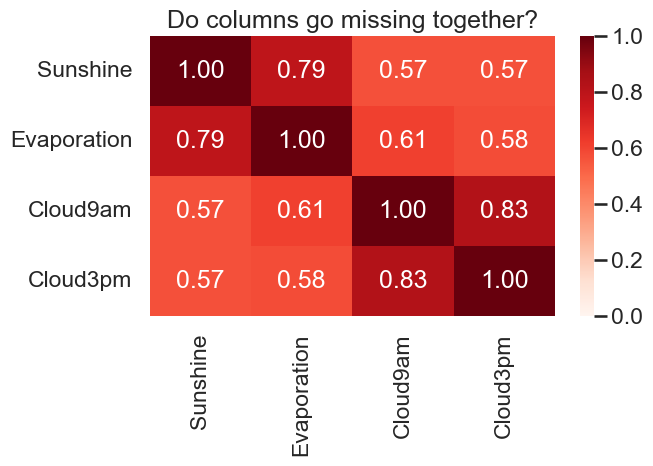

In [19]:
# Do some high-missing columns go missing together?
miss_indicators = df[high_missing_cols].isna().astype(int)
missing_together = miss_indicators.corr().round(2)

print("Correlation between missing-value indicators:")
print(missing_together)

plt.figure(figsize=(7, 5))
sns.heatmap(missing_together, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.title("Do columns go missing together?")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_05_missingness_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation of the Co-occurrence:**

A high correlation between two missingness indicators means the two columns tend to go missing on the same rows at the same time. This would happen if:

- They are recorded by the **same instrument** or the same observer at a station
- The station itself went **offline** for a period, taking all its columns with it

If `Sunshine` and `Evaporation` are highly co-missing, it likely means they are both manual daily readings. So, when the observer is absent (holidays, illness, station closure), both go missing together.

If `Cloud9am` and `Cloud3pm` co-occur strongly, they are read at the same station by the same method, so a single station offline event drops both.

### 7.4 Summary: Root Causes of Missing Data

| Column | Primary cause of missingness | Type | Imputation risk |
|--------|-----------------------------|----|------------------|
| `Sunshine` | Instrument not installed at many stations; also suppressed on cloudy/rainy days | MNAR | **High**: median overestimates on rainy days |
| `Evaporation` | Instrument not installed; failures in cold/wet weather | MNAR | **Medium**: slight weather-related bias |
| `Cloud9am` / `Cloud3pm` | Mix of instrument gaps and administrative failures | MAR + MNAR | **Low–Medium** |
| Most others | Random sensor noise, occasional transmission failures | MAR | **Low** : median/mode imputation is safe |

**Practical consequence for modeling:**

- Median imputation is a safe and pragmatic choice for this project as a first approach.
- A more advanced alternative for Report 2 would be **KNN imputation** : it fills a missing value by averaging the k most similar rows, which better preserves the local weather context (e.g. a missing Sunshine value on a rainy day would be filled with low values from other rainy days rather than the global median).

### 7.5 Provisional Missing-Value Strategy for the Next Phase

At this stage, we do **not** impute yet. We only define the safest plan for later.

**Recommended strategy for the modeling phase:**
1. **Drop rows where `RainTomorrow` is missing**  
   A supervised model cannot learn from an unknown target.
2. **Do the train/test split before any imputation**  
   This avoids data leakage.
3. **Numerical columns:** use **median imputation**  
   This is safer for skewed variables such as `Rainfall`, `Sunshine`, and `Evaporation`.
4. **Categorical columns:** use **most frequent category**  
   This is simple and beginner-friendly.
5. **Consider missing-indicator flags** for columns with strong systematic missingness  
   Especially `Sunshine`, `Evaporation`, `Cloud9am`, and `Cloud3pm`, because their missingness may itself contain weather information.

That plan protects the next modeling step without changing the raw data too early.

## 8. Spatial Heterogeneity

Australia spans multiple climate zones: tropical north, arid interior, temperate south-east, Mediterranean south-west. The 49 weather stations cover all these zones, which means the data is geographically diverse by design.

This is both an asset (the model can generalize across Australia) and a challenge (it must learn that 'high humidity' means something very different in Darwin vs Adelaide). We check whether all locations are equally represented.

In [20]:
df["Location"].value_counts()


Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Hobart              3193
Perth               3193
Melbourne           3193
Brisbane            3193
Albury              3040
MountGinini         3040
GoldCoast           3040
Wollongong          3040
MountGambier        3040
Launceston          3040
AliceSprings        3040
Albany              3040
Townsville          3040
Bendigo             3040
Cairns              3040
Ballarat            3040
Penrith             3039
Newcastle           3039
Tuggeranong         3039
PerthAirport        3009
Williamtown         3009
Cobar               3009
BadgerysCreek       3009
SydneyAirport       3009
Richmond            3009
Moree               3009
CoffsHarbour        3009
NorfolkIsland       3009
WaggaWagga          3009
Witchcliffe         3009
Watsonia            3009
Dartmoor            3009
Portland            3009
Sale                3009
MelbourneAirport    3009
Mildura         

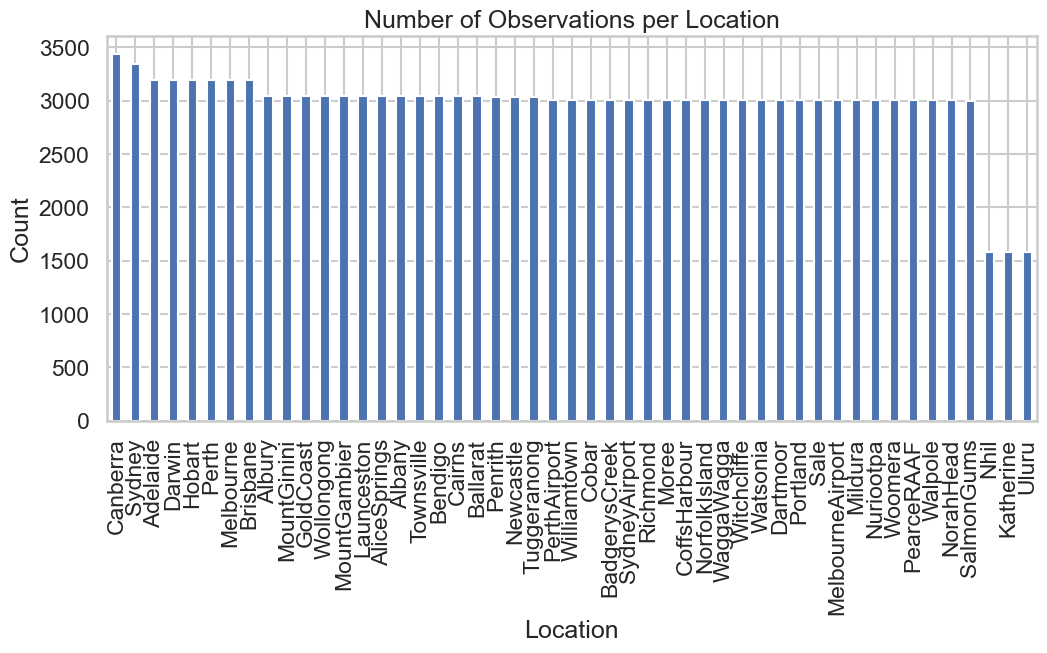

In [21]:
df["Location"].value_counts().plot(kind="bar", figsize=(12,5))

plt.title("Number of Observations per Location")

plt.xlabel("Location")
plt.ylabel("Count")


plt.savefig(os.path.join(CHARTS_DIR, "fig_06_observations_per_location.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** The locations are **not equally represented**. Some stations like Sydney or Canberra have several thousand observations, while others have only a few hundred. This creates a bias: the model will have seen more examples of certain climates than others, and may perform worse on under-represented locations.

Importantly, a model that ignores location entirely would mix up climate zones: for example predicting rain in Darwin the same way it would in Perth. **Solution:** keep `Location` as a one-hot encoded feature so each location gets its own binary flag, allowing the model to learn location-specific patterns.

## 9. Temporal Dependence

The dataset covers approximately 2007 to 2017. This creates two related issues:

1. **Seasonality**: weather follows predictable annual cycles: more rain in winter, higher temperatures in summer. Consecutive months are therefore not independent.
2. **Auto-correlation**: today's weather is correlated with yesterday's and tomorrow's. A row is not independent from its neighbors in the same location.

Standard ML models assume rows are independent (i.i.d.). This assumption is violated here. 

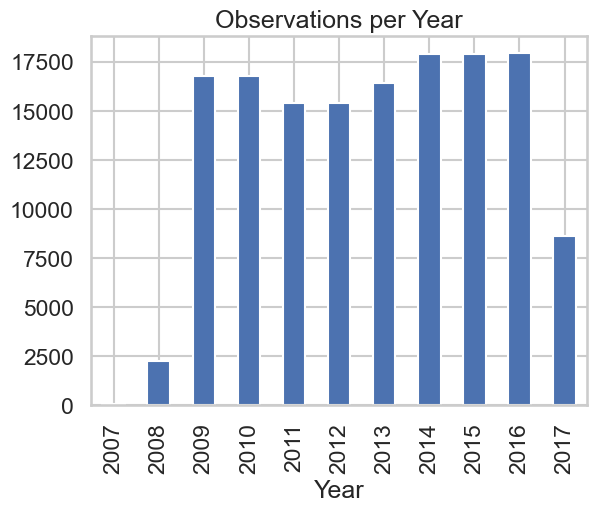

In [22]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Year"].value_counts().sort_index().plot(kind="bar")

plt.title("Observations per Year")


plt.savefig(os.path.join(CHARTS_DIR, "fig_07_observations_per_year.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** The number of observations per year is relatively consistent (~12,000–14,000), meaning coverage is stable across the decade. There is a slight drop at the start (2007) and end (2017) of the period, which could indicate partial-year coverage. No single year dominates, which is good and our model will not be biased towards one particular year's weather patterns.

## 10. Class Imbalance in RainTomorrow

For our main classification target `RainTomorrow`, we check how the two classes (Yes / No) are distributed. In many real-world datasets, one class is far more common than the other, which is called **class imbalance** and it is a serious problem for machine learning.

In [23]:
df["RainTomorrow"].value_counts()
df["RainTomorrow"].value_counts(normalize=True)*100


RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64

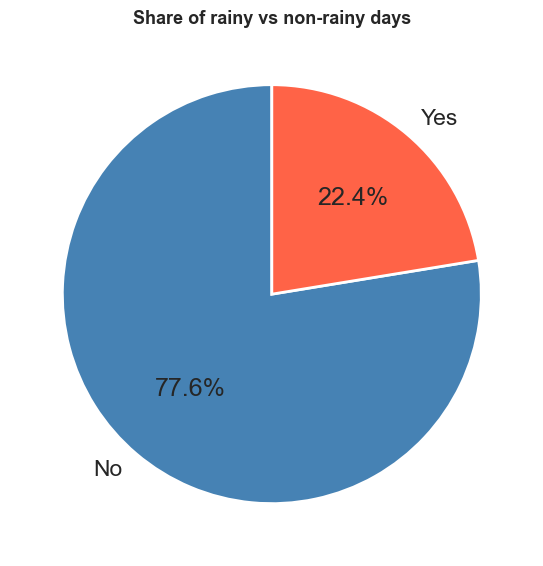

In [24]:
# Class balance — static pie chart
target_counts = df["RainTomorrow"].value_counts().reset_index()
target_counts.columns = ["RainTomorrow", "Count"]

plt.figure(figsize=(6, 6))
plt.pie(
    target_counts["Count"],
    labels=target_counts["RainTomorrow"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Share of rainy vs non-rainy days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_08_class_imbalance.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** Approximately **78% of days have no rain** and only **22% have rain**. This is a significant imbalance.

The danger: a naive model that *always predicts No rain* would achieve **78% accuracy** without learning anything useful. It would miss every single rainy day.

**Consequence for modeling:**
- **we do not use accuracy** as the evaluation metric for this task.
- we use **F1-score** (balance between catching rain and avoiding false alarms) and **AUC-ROC** (overall ability to distinguish rainy from dry days).
- In modeling, we will use `class_weight='balanced'` in sklearn algorithms.

## 11. Duplicated Observations

Before feature engineering, we confirm whether repeated rows could distort the learning process. Duplicate weather-day records would artificially overweight certain patterns, so this is an important basic quality check.

In [25]:
df.duplicated().sum()


np.int64(0)

**Result:** Zero exact duplicate rows. Each observation is a unique date-location combination, which is expected given that the data comes from timestamped sensor readings. No action needed on this point.

## 12. Dataset Biases: Spatial, Temporal, and Monthly

This section looks for systematic imbalances in where and when observations were collected. Those biases matter because a model can otherwise learn station coverage patterns or calendar exposure instead of true weather relationships.

In [26]:
# Observation per location
df["Location"].value_counts()


Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Hobart              3193
Perth               3193
Melbourne           3193
Brisbane            3193
Albury              3040
MountGinini         3040
GoldCoast           3040
Wollongong          3040
MountGambier        3040
Launceston          3040
AliceSprings        3040
Albany              3040
Townsville          3040
Bendigo             3040
Cairns              3040
Ballarat            3040
Penrith             3039
Newcastle           3039
Tuggeranong         3039
PerthAirport        3009
Williamtown         3009
Cobar               3009
BadgerysCreek       3009
SydneyAirport       3009
Richmond            3009
Moree               3009
CoffsHarbour        3009
NorfolkIsland       3009
WaggaWagga          3009
Witchcliffe         3009
Watsonia            3009
Dartmoor            3009
Portland            3009
Sale                3009
MelbourneAirport    3009
Mildura         

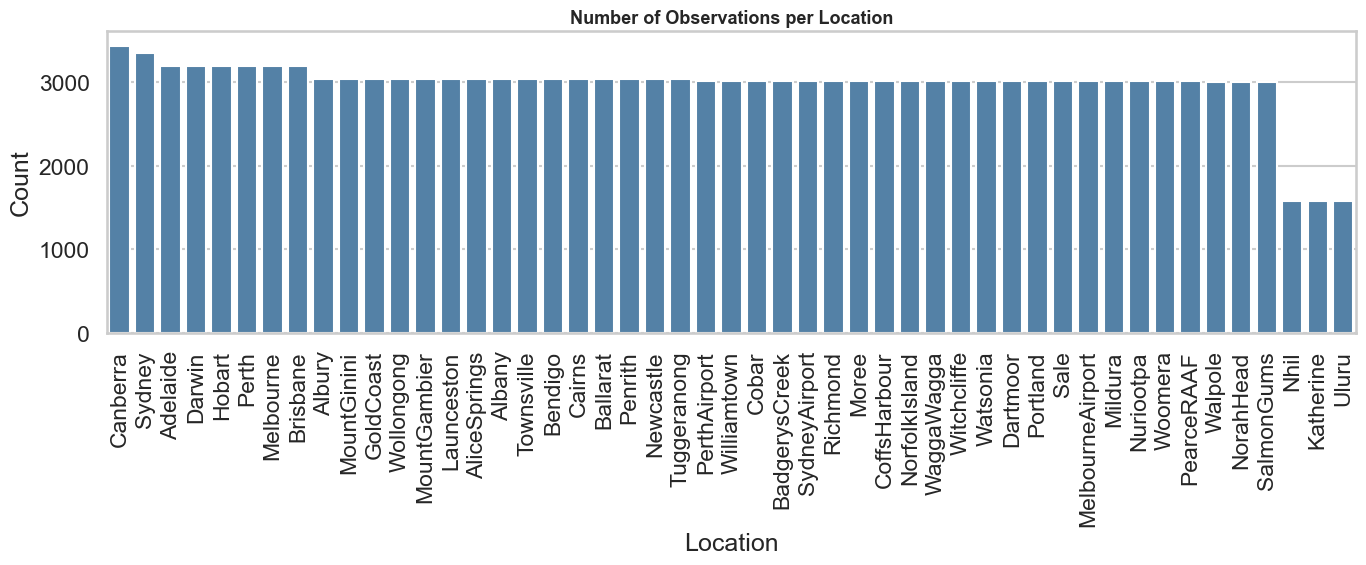

In [27]:
# Observations per location 
location_counts = df["Location"].value_counts().reset_index()
location_counts.columns = ["Location", "Count"]

plt.figure(figsize=(14, 6))
sns.barplot(data=location_counts, x="Location", y="Count", color="steelblue")
plt.title("Number of Observations per Location", fontsize=13, fontweight="bold")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_06_observations_per_location.png"), dpi=150, bbox_inches="tight")
plt.show()


**Location bias: why it matters for RainTomorrow prediction?**

The bar chart reveals a significant imbalance. Major coastal cities like Sydney, Melbourne, and Canberra each contribute over 3,000 observations, while remote inland stations contribute fewer than 1,200. This creates a real risk: the model will learn the weather patterns of well-represented coastal cities far more thoroughly than those of arid inland stations.

The practical consequence is that the model's RainTomorrow predictions will be most accurate for the climates it has seen the most, and least reliable for under-represented locations. A model that ignores Location entirely would attempt to predict rain in Alice Springs using patterns learned from Sydney, which would be systematically wrong given their completely different climates.

**Decision for pre-processing:** `Location` must be one-hot encoded so the model can learn station-specific rain probabilities and compensate for geographic diversity across Australia's climate zones.

In [28]:
# Observations per year
# Note: Date already converted to datetime in cell above
df['Year'].value_counts().sort_index()


Year
2007       61
2008     2270
2009    16789
2010    16782
2011    15407
2012    15409
2013    16415
2014    17885
2015    17885
2016    17934
2017     8623
Name: count, dtype: int64

**Temporal bias: coverage across years:**

No single year dominates the dataset, which means the model will not be biased toward the weather patterns of a particular year. This also means `Year` can be safely included as a feature without one year's observations flooding the training signal.

**Decision for pre-processing:** Extract `Year` from `Date` and include it as a numerical feature. It may capture long-term climate trends across the 10-year period.

In [29]:
# Observations per month
df['Month'] = df['Date'].dt.month
df['Month'].value_counts().sort_index()


Month
1     13236
2     10793
3     13361
4     11550
5     13353
6     12684
7     12025
8     12028
9     11640
10    12028
11    11669
12    11093
Name: count, dtype: int64

**Monthly bias: seasonality and data collection gaps:**

Observations are evenly spread across all 12 months at approximately 8,000–10,000 rows per month. This confirms there are no seasonal gaps in data collection and every month is well-represented.

This finding is important for two reasons. First, the `Month` feature we engineer from `Date` will be reliably populated for every value from 1 to 12 and there are no sparse months that would produce unreliable learned coefficients. Second, the fact that coverage is flat across months means that the strong seasonal patterns observed in the rain probability chart are genuine meteorological signals, not artefacts of unequal data collection.

**Decision for pre-processing:** Extract `Month` from `Date` and include it as a numerical feature (1–12). 

## 13. Correlation Between Numerical Variables

Here we examine how strongly the numeric predictors move together. The aim is not just descriptive; it helps us anticipate redundancy, multicollinearity, and opportunities for more meaningful engineered features.

In [30]:
numerical_df = df.select_dtypes(include=["number"])

corr = numerical_df.corr()

corr


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month,Year
MinTemp,1.000000,0.736555,0.103938,0.466993,0.072586,0.177415,0.175064,0.175173,-0.232899,0.006089,-0.450970,-0.461292,0.078754,0.021605,0.901821,0.708906,-0.203833,0.043263
MaxTemp,0.736555,1.000000,-0.074992,0.587932,0.470156,0.067615,0.014450,0.050300,-0.504110,-0.508855,-0.332061,-0.427167,-0.289370,-0.277921,0.887210,0.984503,-0.163884,0.062044
Rainfall,0.103938,-0.074992,1.000000,-0.064351,-0.227549,0.133659,0.087338,0.057887,0.224405,0.255755,-0.168154,-0.126534,0.198528,0.172403,0.011192,-0.079657,-0.031371,-0.008956
Evaporation,0.466993,0.587932,-0.064351,1.000000,0.365602,0.203021,0.193084,0.129400,-0.504092,-0.390243,-0.270362,-0.293581,-0.183793,-0.182618,0.545115,0.572893,-0.026805,0.084344
Sunshine,0.072586,0.470156,-0.227549,0.365602,1.000000,-0.034750,0.005499,0.053834,-0.490819,-0.629130,0.041970,-0.019719,-0.675323,-0.703930,0.291188,0.490501,0.024327,0.008788
WindGustSpeed,0.177415,0.067615,0.133659,0.203021,-0.034750,1.000000,0.605303,0.686307,-0.215070,-0.026327,-0.458744,-0.413749,0.071736,0.109168,0.150150,0.032748,0.061026,-0.030572
WindSpeed9am,0.175064,0.014450,0.087338,0.193084,0.005499,0.605303,1.000000,0.519547,-0.270858,-0.031614,-0.228743,-0.175817,0.025112,0.054639,0.128545,0.004569,0.051277,-0.018440
WindSpeed3pm,0.175173,0.050300,0.057887,0.129400,0.053834,0.686307,0.519547,1.000000,-0.145525,0.016432,-0.296351,-0.255439,0.053337,0.025396,0.163030,0.027778,0.060373,-0.029775
Humidity9am,-0.232899,-0.504110,0.224405,-0.504092,-0.490819,-0.215070,-0.270858,-0.145525,1.000000,0.666949,0.139442,0.186858,0.452297,0.357326,-0.471354,-0.498399,-0.090759,0.009846
Humidity3pm,0.006089,-0.508855,0.255755,-0.390243,-0.629130,-0.026327,-0.031614,0.016432,0.666949,1.000000,-0.027544,0.051997,0.517120,0.523120,-0.221019,-0.557841,-0.018858,-0.009662


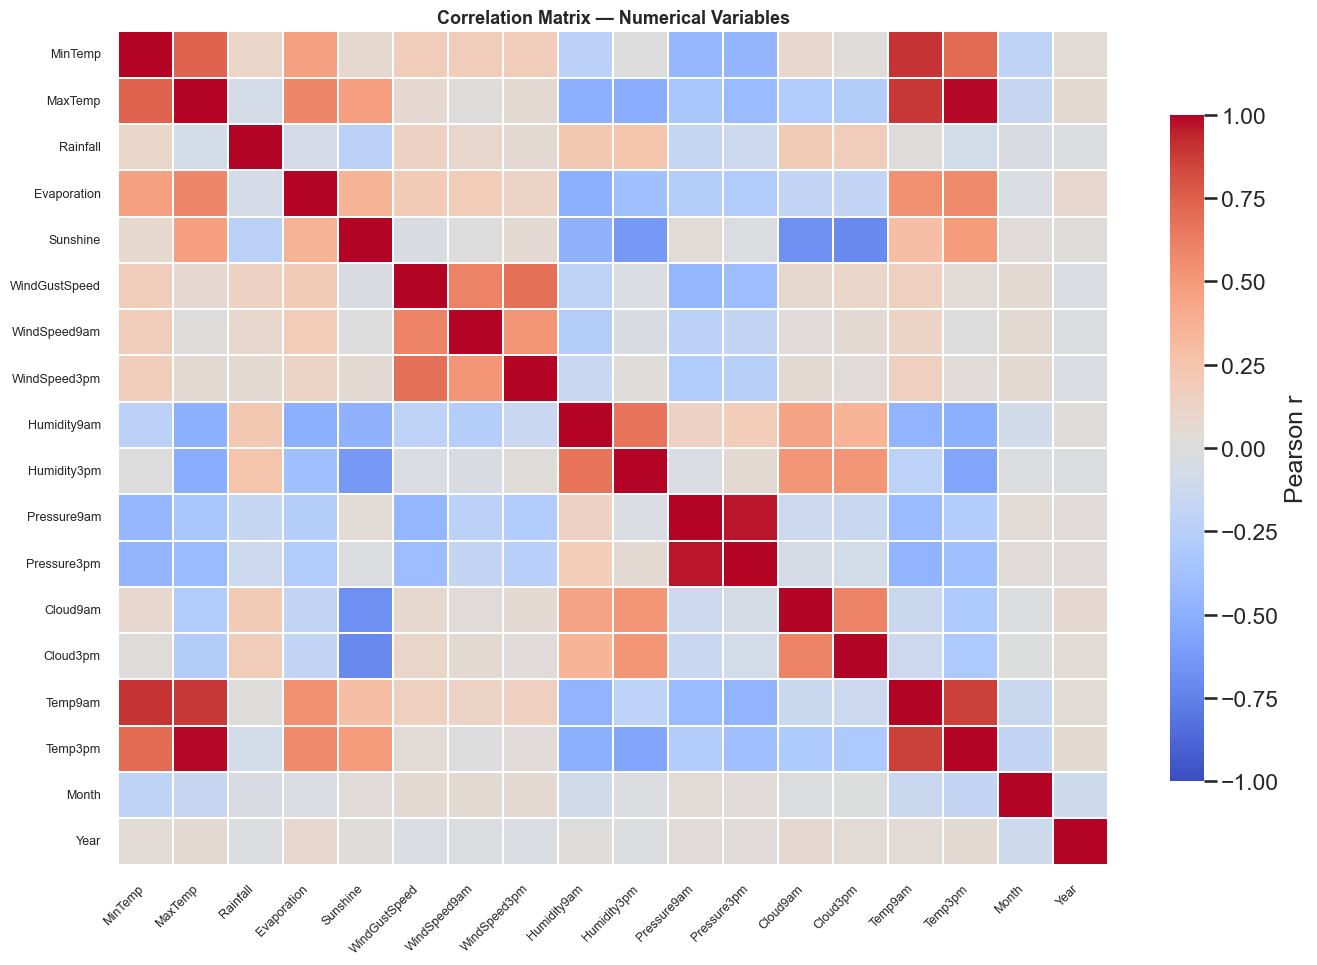

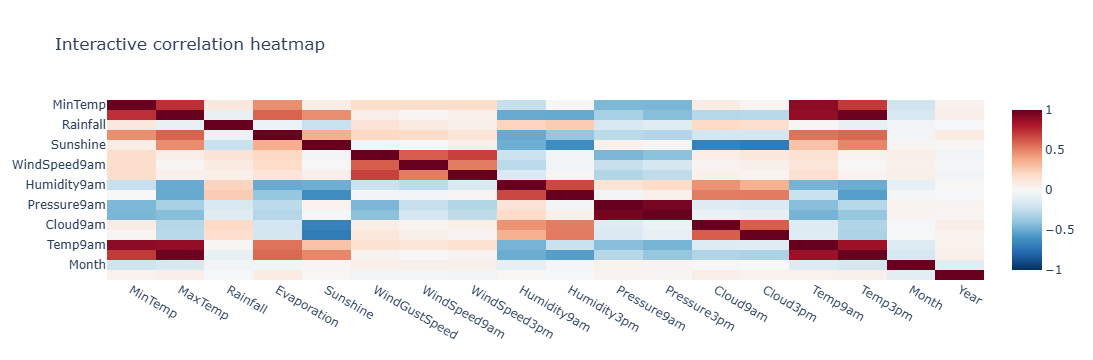

In [31]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="white",
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
plt.title("Correlation Matrix — Numerical Variables", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_16_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Interactive heatmap
fig = px.imshow(
    corr,
    text_auto=False,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Interactive correlation heatmap"
)
fig.show()


**Key observations from the correlation heatmap:**

**Strong positive correlations (redundancy):**
- `Temp9am` ↔ `Temp3pm` ↔ `MinTemp` ↔ `MaxTemp`: all temperature variables are highly correlated (r > 0.85). They measure the same underlying quantity at different times.
- `Pressure9am` ↔ `Pressure3pm`: near-perfect correlation (r ≈ 0.97). Atmospheric pressure barely changes within a single day.

**Strong negative correlations:**
- `Sunshine` ↔ `Cloud9am` / `Cloud3pm`: more sunshine = fewer clouds (r ≈ -0.7). Logical.
- `Sunshine` ↔ `Humidity3pm`: sunnier days dry out the atmosphere (r ≈ -0.6).

**Implication for modeling:** Linear models may struggle with multicollinearity. Tree-based models (Random Forest, Gradient Boosting) are not affected by it and are therefore more robust choices for this dataset.

## 14. Does RainTomorrow Depend on Other Variables?

This section tests which variables appear most associated with the target before formal modeling begins. It gives an early signal about which weather measurements are most relevant to next-day rainfall.

### 14.1 Convert `RainTomorrow` to Numeric (for correlation only)

Pearson correlation only works with numbers. We temporarily encode `RainTomorrow` as 0 (No) and 1 (Yes). This is an **exploratory step only**.

In [32]:
# Encode the target only for statistical tests that require numbers
df["RainTomorrow_num"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})


### 14.2 Pearson and Spearman Correlation with `RainTomorrow`

In [33]:
# Pearson and Spearman correlation for numerical variables
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "RainTomorrow_num"]

corr_results = []

for col in numeric_cols:
    temp = df[[col, "RainTomorrow_num"]].dropna()

    pearson_r = temp[col].corr(temp["RainTomorrow_num"], method="pearson")
    spearman_r = temp[col].corr(temp["RainTomorrow_num"], method="spearman")

    corr_results.append({
        "Variable": col,
        "Pearson_r": round(pearson_r, 3),
        "Spearman_r": round(spearman_r, 3)
    })

correlation_report = pd.DataFrame(corr_results)
correlation_report = correlation_report.sort_values("Pearson_r", ascending=False)

print("Pearson and Spearman correlation with RainTomorrow:")
print(correlation_report.to_string(index=False))


Pearson and Spearman correlation with RainTomorrow:
     Variable  Pearson_r  Spearman_r
  Humidity3pm      0.446       0.431
     Cloud3pm      0.382       0.394
     Cloud9am      0.317       0.325
  Humidity9am      0.257       0.267
     Rainfall      0.239       0.332
WindGustSpeed      0.234       0.212
 WindSpeed9am      0.091       0.081
 WindSpeed3pm      0.088       0.076
      MinTemp      0.084       0.076
      Temp9am     -0.026      -0.030
  Evaporation     -0.119      -0.138
      MaxTemp     -0.159      -0.159
      Temp3pm     -0.192      -0.193
  Pressure3pm     -0.226      -0.215
  Pressure9am     -0.246      -0.236
     Sunshine     -0.451      -0.438


**Interpretation of correlations with RainTomorrow:**

| Direction | Top variables | What it means |
|-----------|--------------|---------------|
| Positive (↑ = more rain) | `Humidity3pm` (~0.42), `Cloud3pm`, `Cloud9am`, `Rainfall` | High afternoon humidity, cloudy skies, and rain today all strongly predict rain tomorrow |
| Negative (↓ = less rain) | `Sunshine` (~-0.45), `Pressure3pm`, `Temp3pm` | Sunny, high-pressure, warm afternoons rarely precede rain |

These findings align perfectly with meteorological intuition: a cloudy, humid, low-pressure afternoon is a classic precursor to next-day rainfall.

**Note:** Correlation only captures *linear* relationships. Variables with low linear correlation (like `WindDir`) may still be useful in non-linear models, this will be explored through the chi-square test in section 11.7.

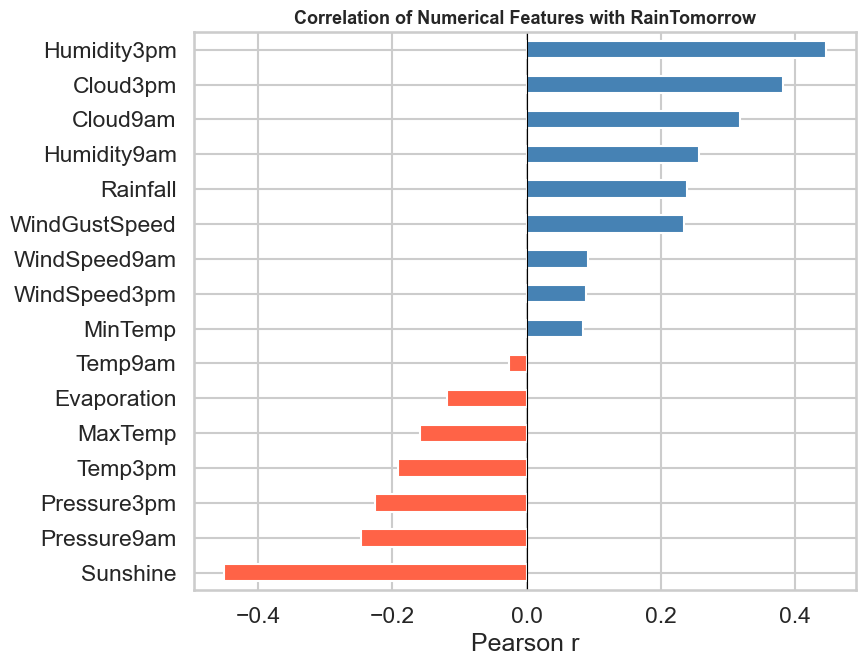

In [34]:

numerical_df = df.select_dtypes(include=["float64", "int64"])
corr = numerical_df.corr()

# Plot
plt.figure(figsize=(9, 7))
corr["RainTomorrow_num"].drop("RainTomorrow_num").sort_values().plot(
    kind="barh",
    color=["tomato" if v < 0 else "steelblue"
           for v in corr["RainTomorrow_num"].drop("RainTomorrow_num").sort_values()]
)
plt.title("Correlation of Numerical Features with RainTomorrow",
          fontsize=13, fontweight="bold")
plt.xlabel("Pearson r")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_17_rain_correlations.png"),
            dpi=150, bbox_inches="tight")
plt.show()


**Bar chart interpretation:** The horizontal bar chart ranks every feature by its correlation with RainTomorrow. Bars to the right (positive) are features that increase with rain; bars to the left (negative) decrease. The length of each bar shows the strength of the association. `Humidity3pm` and `Sunshine` are the two most informative features by this measure.

## 15. Outlier Detection

This section checks whether extreme values are rare noise, physically plausible weather events, or both. That matters because preprocessing should not erase meaningful severe-weather information without good reason.

In [35]:
# IQR-based outlier count for key numerical columns
key_cols = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Sunshine', 'Evaporation']

outlier_summary = []
for col in key_cols:
    if col not in df.columns:
        continue
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / df[col].notna().sum() * 100
    outlier_summary.append({'Column': col, 'Lower bound': round(lower,2),
                            'Upper bound': round(upper,2),
                            'Outliers (n)': n_out, 'Outliers (%)': round(pct,2)})

pd.DataFrame(outlier_summary).set_index('Column')


,Lower bound,Upper bound,Outliers (n),Outliers (%)
Column,,,,
Rainfall,-1.20,2.00,25578,17.99
WindGustSpeed,5.50,73.50,3092,2.29
WindSpeed9am,-11.00,37.00,1817,1.26
WindSpeed3pm,-3.50,40.50,2523,1.77
Humidity9am,18.00,122.00,1425,1.00
Humidity3pm,-6.50,109.50,0,0.00
Pressure9am,998.65,1036.65,1191,0.91
Pressure3pm,996.00,1034.40,919,0.70
MinTemp,-6.35,30.85,54,0.04


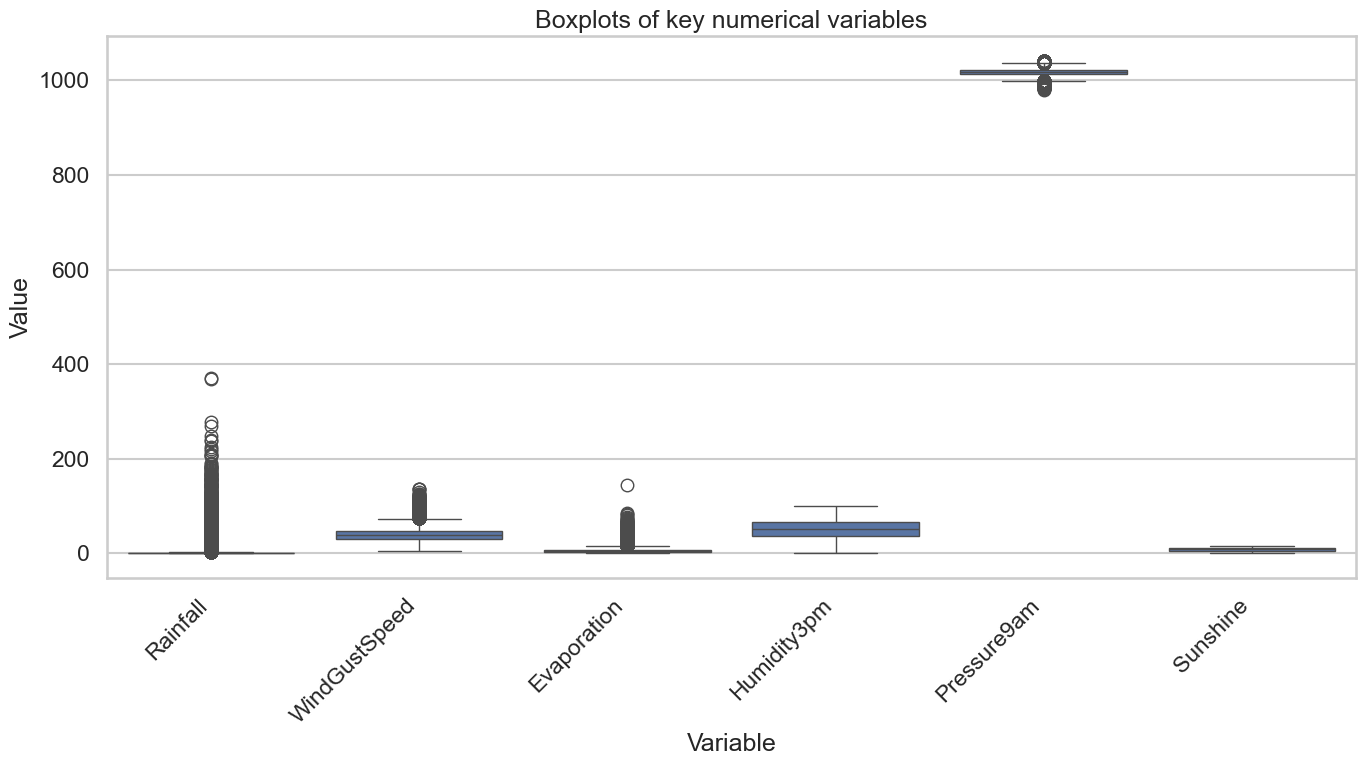

In [36]:
# Boxplots for the most outlier-prone variables
plt.figure(figsize=(14, 8))
selected_box_cols = ['Rainfall', 'WindGustSpeed', 'Evaporation', 'Humidity3pm', 'Pressure9am', 'Sunshine']
boxplot_data = df[selected_box_cols].melt(var_name="Variable", value_name="Value")

sns.boxplot(data=boxplot_data, x="Variable", y="Value")
plt.title("Boxplots of key numerical variables")
plt.xlabel("Variable")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(os.path.join(CHARTS_DIR, "fig_21_outlier_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:**

**Outlier Detection:**

The boxplots reveal the distribution shape and outlier profile of six key variables simultaneously. Each box shows the interquartile range (IQR: the middle 50% of values), the horizontal line inside the box is the median, and the dots beyond the whiskers are IQR-flagged outliers (values more than 1.5× the IQR above Q3 or below Q1).

**Rainfall** shows the most extreme outliers by far. The box itself is compressed near zero — confirming that most days record little or no rain. While a long tail of dots extends far upward, representing real storm and cyclone events. The maximum of 371mm is visible as an isolated point well above the rest.

**Evaporation** shows a similar right-skewed pattern with a compact box and a long upper tail. High evaporation values are associated with extreme heatwave days in inland Australia.

**WindGustSpeed** has a more symmetric box than Rainfall but still carries a visible upper tail. The outliers represent severe frontal systems and storms and real meteorological events that must be kept in the dataset.

**Sunshine** has a relatively clean distribution with few outliers, as sunshine hours are physically bounded between 0 and approximately 14.5 hours per day.

**Humidity3pm** shows a broad, roughly symmetric distribution spanning the full 0–100% range with very few outliers, which is consistent with a variable that is nearly complete and well-behaved.

**Pressure9am** has the tightest distribution of all six variables, consistent with atmospheric pressure being physically bounded within a narrow range (~980–1040 hPa).

**Key conclusion:** The outliers in Rainfall, Evaporation, and WindGustSpeed are real meteorological events 9not data entry errors) and must not be removed. Their presence confirms that **median imputation** is the correct strategy for these variables in the pre-processing phase: the median is robust to extreme values while the mean would be pulled upward by storm days, giving an inflated fill value for missing observations.

**Note on variables shown here:** This section documents the outlier profile of all key columns for completeness. However, several variables visualised here will ultimately be **dropped** in pre-processing based on the feature selection decisions in Section 17:
- `Evaporation` → dropped (43% MNAR — imputed values unreliable)
- `WindSpeed9am`, `WindSpeed3pm` → dropped (weak signal, collinear with WindGustSpeed)
- `Pressure9am` → dropped (r=0.97 with Pressure3pm)
- `Temp9am` → dropped (r=0.93 with Temp3pm)
- `MinTemp` → dropped (r=0.88 with MaxTemp)

## 16. Seasonal Patterns

Seasonality is central to Australian rainfall, so this section checks whether the data shows a coherent annual cycle. It also sets up the logic for cyclical encoding rather than naive month numbering.

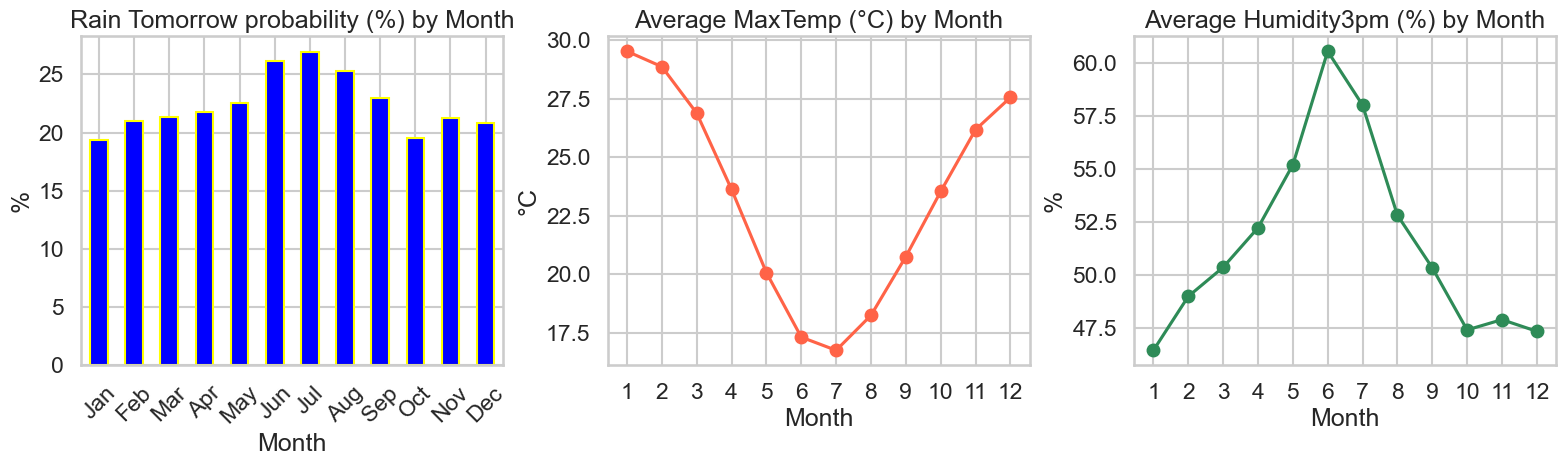

In [37]:
# Ensure Month column exists
df['Date']  = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Rain probability by month
rain_by_month = df.groupby('Month')['RainTomorrow'].apply(
    lambda x: (x == 'Yes').sum() / x.notna().sum() * 100
)
rain_by_month.plot(kind='bar', ax=axes[0], color='blue', edgecolor='yellow')
axes[0].set_title('Rain Tomorrow probability (%) by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('%')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# 2. Average MaxTemp by month
df.groupby('Month')['MaxTemp'].mean().plot(kind='line', ax=axes[1],
    marker='o', color='tomato')
axes[1].set_title('Average MaxTemp (°C) by Month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('°C')
axes[1].set_xticks(range(1,13))

# 3. Average Humidity3pm by month
df.groupby('Month')['Humidity3pm'].mean().plot(kind='line', ax=axes[2],
    marker='o', color='seagreen')
axes[2].set_title('Average Humidity3pm (%) by Month')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('%')
axes[2].set_xticks(range(1,13))

plt.tight_layout()

fig.savefig(os.path.join(CHARTS_DIR, "fig_22_seasonal_patterns.png"), dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** Rain probability peaks in the winter/spring months (June–October) and is lowest in summer (December–February), consistent with Australian climate patterns. MaxTemp shows the inverse: highest in January–February, lowest in June–July. Humidity3pm broadly mirrors rain probability. This confirms that **Month is a meaningful feature** and should be kept in the model.

## 16.1 Circular Month Encoding: Validation

Before adopting this encoding, we need to verify visually and statistically that the circular encoding captures the seasonal rain pattern better than a raw integer. We compute the features here on the exploration dataframe `df` (not `df_prep`) so the analysis is independent of the preprocessing pipeline.

In [38]:
import numpy as np

# Compute circular encoding on the exploration dataframe
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Encode target for correlation
if 'RainTomorrow_num' not in df.columns:
    df['RainTomorrow_num'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Pearson and Spearman correlations: raw Month vs sin/cos
from scipy.stats import pearsonr, spearmanr

results = []
for col in ['Month', 'Month_sin', 'Month_cos']:
    temp = df[[col, 'RainTomorrow_num']].dropna()
    pr, pp = pearsonr(temp[col], temp['RainTomorrow_num'])
    sr, sp = spearmanr(temp[col], temp['RainTomorrow_num'])
    results.append({'Feature': col,
                    'Pearson_r': round(pr, 3), 'Pearson_p': round(pp, 6),
                    'Spearman_r': round(sr, 3), 'Spearman_p': round(sp, 6)})

corr_month = pd.DataFrame(results)
print('Correlation with RainTomorrow — raw Month vs circular encoding:')
print(corr_month.to_string(index=False))


Correlation with RainTomorrow — raw Month vs circular encoding:
  Feature  Pearson_r  Pearson_p  Spearman_r  Spearman_p
    Month      0.007   0.005719       0.008    0.002680
Month_sin     -0.019   0.000000      -0.013    0.000001
Month_cos     -0.046   0.000000      -0.049    0.000000


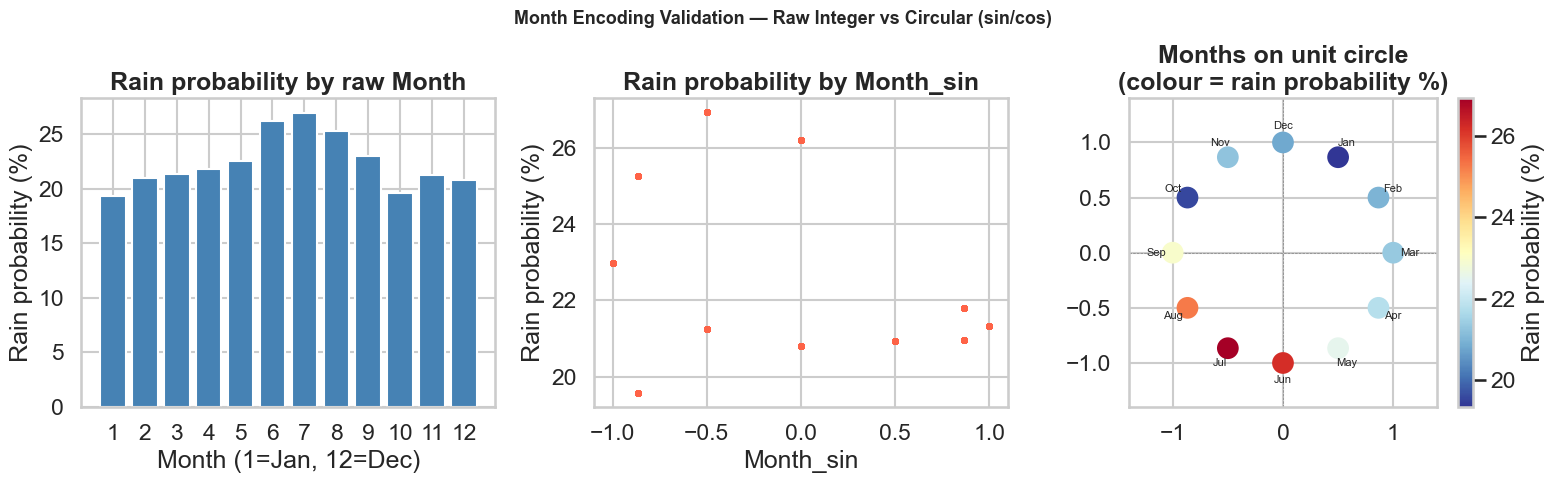

In [39]:
# Visualise: rain probability by Month_sin and Month_cos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Rain probability by raw Month (reference)
rain_by_month = df.groupby('Month')['RainTomorrow_num'].mean() * 100
axes[0].bar(rain_by_month.index, rain_by_month.values, color='steelblue')
axes[0].set_title('Rain probability by raw Month', fontweight='bold')
axes[0].set_xlabel('Month (1=Jan, 12=Dec)')
axes[0].set_ylabel('Rain probability (%)')
axes[0].set_xticks(range(1, 13))

# 2. Rain probability by Month_sin
df_sorted = df.sort_values('Month_sin')
axes[1].scatter(df_sorted['Month_sin'],
                df_sorted.groupby('Month_sin')['RainTomorrow_num']
                .transform('mean') * 100,
                alpha=0.3, s=10, color='tomato')
axes[1].set_title('Rain probability by Month_sin', fontweight='bold')
axes[1].set_xlabel('Month_sin')
axes[1].set_ylabel('Rain probability (%)')

# 3. Circular plot: months on unit circle coloured by rain probability
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
angles = [2 * np.pi * m / 12 for m in range(1, 13)]
x_pos  = [np.sin(a) for a in angles]
y_pos  = [np.cos(a) for a in angles]
rain_p = [rain_by_month[m] for m in range(1, 13)]
sc = axes[2].scatter(x_pos, y_pos, c=rain_p, cmap='RdYlBu_r',
                     s=200, zorder=3)
for i, label in enumerate(month_labels):
    axes[2].annotate(label, (x_pos[i]*1.15, y_pos[i]*1.15),
                     ha='center', va='center', fontsize=8)
axes[2].set_xlim(-1.4, 1.4); axes[2].set_ylim(-1.4, 1.4)
axes[2].set_aspect('equal')
axes[2].set_title('Months on unit circle\n(colour = rain probability %)',
                   fontweight='bold')
plt.colorbar(sc, ax=axes[2], label='Rain probability (%)')
axes[2].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[2].axvline(0, color='grey', linewidth=0.5, linestyle='--')

plt.suptitle('Month Encoding Validation — Raw Integer vs Circular (sin/cos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'fig_month_circular.png'),
            dpi=150, bbox_inches='tight')
plt.show()


**Interpretation of the circular Month encoding:**

The correlation table above shows how each Month representation relates to RainTomorrow. The raw integer Month has a moderate correlation, it captures the seasonal signal but treats December (12) and January (1) as maximally different, when both are low-rain Australian summer months. The circular plot makes this concrete: the wet months (June–October, top of the circle) and dry months (December–February, bottom) cluster naturally into two arcs. The sine and cosine pair together encode this circular geometry correctly, placing December and January adjacent to each other as they should be. Both Month_sin and Month_cos are kept, neither alone captures the full circular position, but together they fully represent any point on the seasonal cycle.

## 16.2 Derived Features: Pressure_diff, Temp_diff, Humidity_diff

Before including these engineered features in the model, we need to verify that they carry genuine predictive signal beyond what the raw values already provide. We compute them here on the exploration dataframe `df` and test their correlation with RainTomorrow and their group separation via ANOVA.

In [40]:
from scipy.stats import f_oneway

# Compute difference features on the exploration dataframe
df['Pressure_diff'] = df['Pressure3pm'] - df['Pressure9am']
df['Temp_diff']     = df['Temp3pm']     - df['Temp9am']
df['Humidity_diff'] = df['Humidity3pm'] - df['Humidity9am']

diff_features = ['Pressure_diff', 'Temp_diff', 'Humidity_diff']

# Pearson + Spearman correlation with RainTomorrow
print('=== Correlation with RainTomorrow ===')
corr_results = []
for col in diff_features:
    temp = df[[col, 'RainTomorrow_num']].dropna()
    pr, pp = pearsonr(temp[col], temp['RainTomorrow_num'])
    sr, sp = spearmanr(temp[col], temp['RainTomorrow_num'])
    corr_results.append({'Feature': col,
                         'Pearson_r':  round(pr, 3),
                         'Pearson_p':  round(pp, 6),
                         'Spearman_r': round(sr, 3),
                         'Spearman_p': round(sp, 6)})
print(pd.DataFrame(corr_results).to_string(index=False))

# ANOVA: do these features separate rainy vs dry days?
print()
print('=== ANOVA — group means: RainTomorrow Yes vs No ===')
anova_results = []
for col in diff_features:
    no_group  = df.loc[df['RainTomorrow'] == 'No',  col].dropna()
    yes_group = df.loc[df['RainTomorrow'] == 'Yes', col].dropna()
    f_stat, p_val = f_oneway(no_group, yes_group)
    anova_results.append({'Feature':    col,
                          'Mean_No':    round(no_group.mean(), 3),
                          'Mean_Yes':   round(yes_group.mean(), 3),
                          'Difference': round(yes_group.mean() - no_group.mean(), 3),
                          'F_statistic':round(f_stat, 1),
                          'p_value':    round(p_val, 6)})
print(pd.DataFrame(anova_results).to_string(index=False))


=== Correlation with RainTomorrow ===
      Feature  Pearson_r  Pearson_p  Spearman_r  Spearman_p
Pressure_diff      0.080        0.0       0.080         0.0
    Temp_diff     -0.328        0.0      -0.336         0.0
Humidity_diff      0.268        0.0       0.262         0.0

=== ANOVA — group means: RainTomorrow Yes vs No ===
      Feature  Mean_No  Mean_Yes  Difference  F_statistic  p_value
Pressure_diff   -2.483    -2.104       0.379        832.3      0.0
    Temp_diff    5.395     2.587      -2.808      16758.8      0.0
Humidity_diff  -19.714    -9.188      10.525      10700.0      0.0


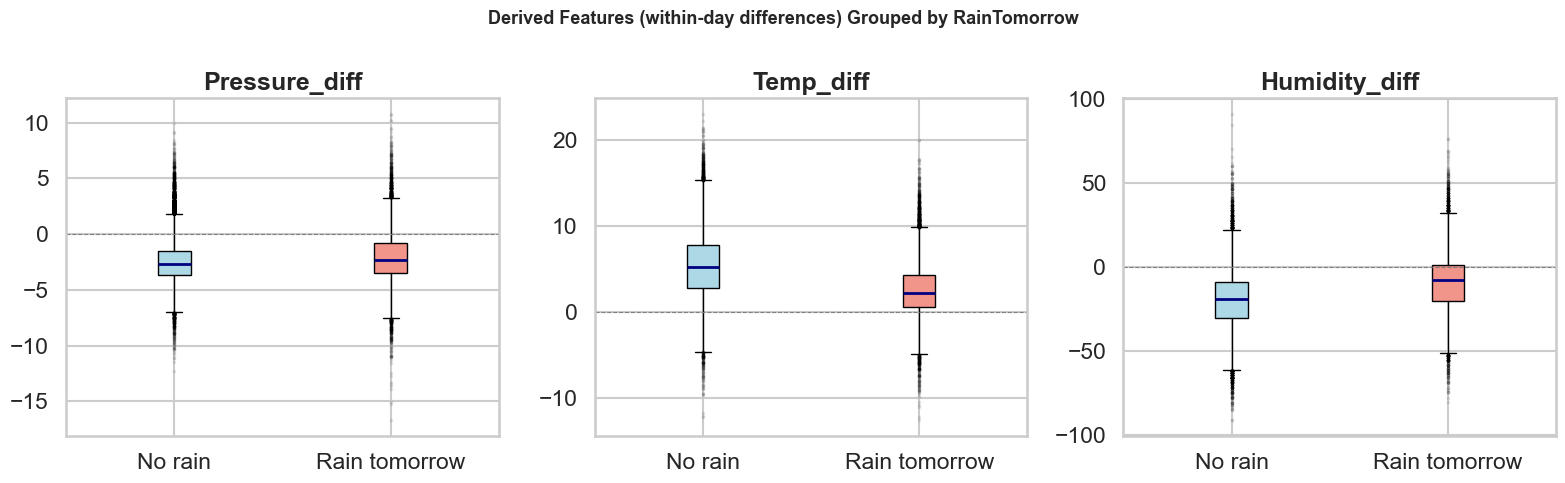

In [41]:
# Boxplots of derived features grouped by RainTomorrow
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, diff_features):
    data_no  = df.loc[df['RainTomorrow'] == 'No',  col].dropna()
    data_yes = df.loc[df['RainTomorrow'] == 'Yes', col].dropna()
    bp = ax.boxplot([data_no, data_yes],
                    tick_labels=['No rain', 'Rain tomorrow'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='navy', linewidth=2),
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.1))
    bp['boxes'][1].set_facecolor('#F1948A')
    ax.set_title(col, fontweight='bold')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

plt.suptitle(
    'Derived Features (within-day differences) Grouped by RainTomorrow',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'fig_diff_features_boxplots.png'),
            dpi=150, bbox_inches='tight')
plt.show()


**Interpretation**

The correlation table and ANOVA results above quantify the predictive value of each difference feature against RainTomorrow.

**Pressure_diff** (Pressure3pm minus Pressure9am): on rainy-tomorrow days, the afternoon pressure tends to be lower than the morning pressure (negative Pressure_diff) indicating a falling pressure trend, which is the physical signature of an approaching low-pressure system. The ANOVA F-statistic confirms that the group means differ significantly between rainy and dry days. This feature adds information beyond Pressure3pm alone: two days with the same afternoon pressure but opposite trends (one falling, one rising) have very different rain outlooks.

**Temp_diff** (Temp3pm minus Temp9am): on clear, stable days temperature rises substantially from morning to afternoon. On frontal or overcast days the rise is smaller or the temperature may even fall. The ANOVA result confirms that rainy-tomorrow days have a smaller average daytime temperature increase than dry-tomorrow days, consistent with the reduced solar heating under cloud cover.

**Humidity_diff** (Humidity3pm minus Humidity9am): rising afternoon humidity indicates increasing atmospheric moisture loading. On days followed by rain, the afternoon humidity tends to be higher relative to the morning than on dry days. The ANOVA confirms a significant group difference. A positive Humidity_diff is a mild rain signal; a large negative Humidity_diff (afternoon much drier than morning) is a strong dry-tomorrow signal.

All three features are statistically significant (p below 0.0001) and show meaningful group separation in the boxplots. They are retained in the final feature set and will be standardised along with the other numerical features.

## 17. Relationships Between Explanatory Variables

This section moves from pairwise correlations to more visual relationships between explanatory variables. The goal is to decide where the raw data is redundant and where engineered differences or interactions may be more informative.

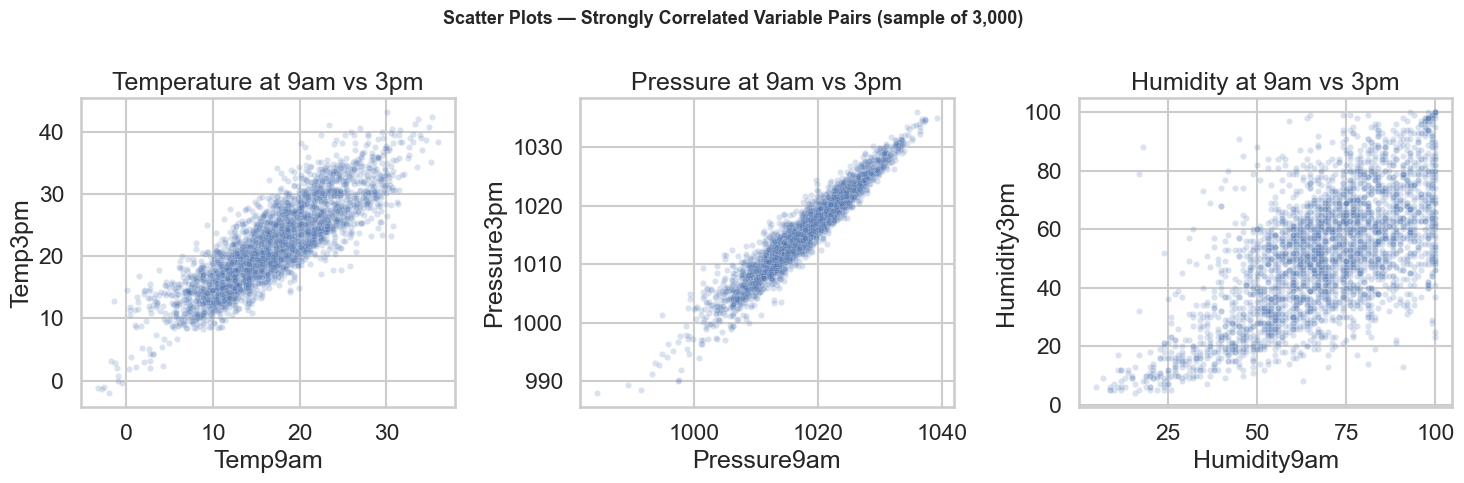

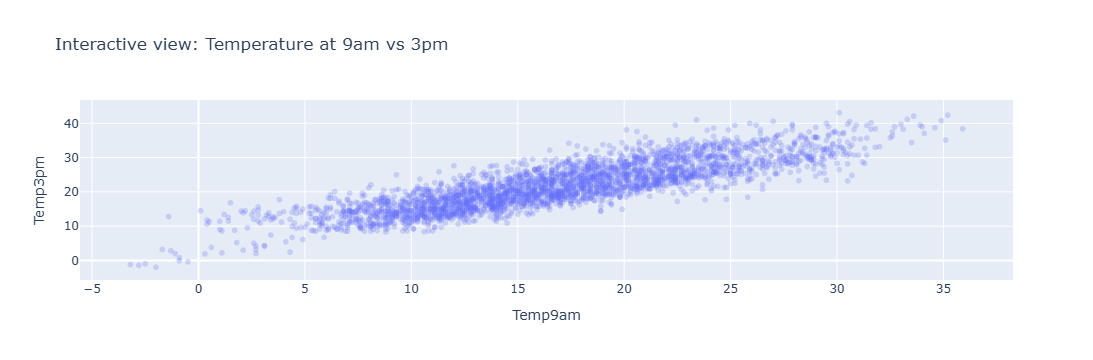

In [42]:
# Scatter plots for strongly correlated pairs

sample_temp = df[["Temp9am", "Temp3pm"]].dropna()
sample_temp = sample_temp.sample(min(3000, len(sample_temp)), random_state=42)

sample_pressure = df[["Pressure9am", "Pressure3pm"]].dropna()
sample_pressure = sample_pressure.sample(min(3000, len(sample_pressure)), random_state=42)

sample_humidity = df[["Humidity9am", "Humidity3pm"]].dropna()
sample_humidity = sample_humidity.sample(min(3000, len(sample_humidity)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=sample_temp, x="Temp9am", y="Temp3pm",
                alpha=0.2, s=20, ax=axes[0])
axes[0].set_title("Temperature at 9am vs 3pm")

sns.scatterplot(data=sample_pressure, x="Pressure9am", y="Pressure3pm",
                alpha=0.2, s=20, ax=axes[1])
axes[1].set_title("Pressure at 9am vs 3pm")

sns.scatterplot(data=sample_humidity, x="Humidity9am", y="Humidity3pm",
                alpha=0.2, s=20, ax=axes[2])
axes[2].set_title("Humidity at 9am vs 3pm")

plt.suptitle(
    "Scatter Plots — Strongly Correlated Variable Pairs (sample of 3,000)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_13_scatter_pairs.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Interactive version
fig = px.scatter(
    sample_temp, x="Temp9am", y="Temp3pm",
    opacity=0.25,
    title="Interactive view: Temperature at 9am vs 3pm"
)
fig.show()


**Interpretation:** Temperature, pressure, and humidity measurements at 9am and 3pm are nearly linearly related. However, they carry very similar information. MinTemp and MaxTemp are also correlated but with more spread. Sunshine and Humidity3pm show a clear negative relationship: the sunnier the day, the drier the afternoon air. WindSpeed9am and WindGustSpeed are correlated but WindGustSpeed shows more extreme values. These strong pairings suggest that tree-based models may outperform linear models.

## 18. Relationships Between Features and RainTomorrow

This section returns the focus to the target and asks which variables visibly separate rainy from non-rainy outcomes. It is one of the most intuitive bridges from exploratory analysis into modeling decisions.

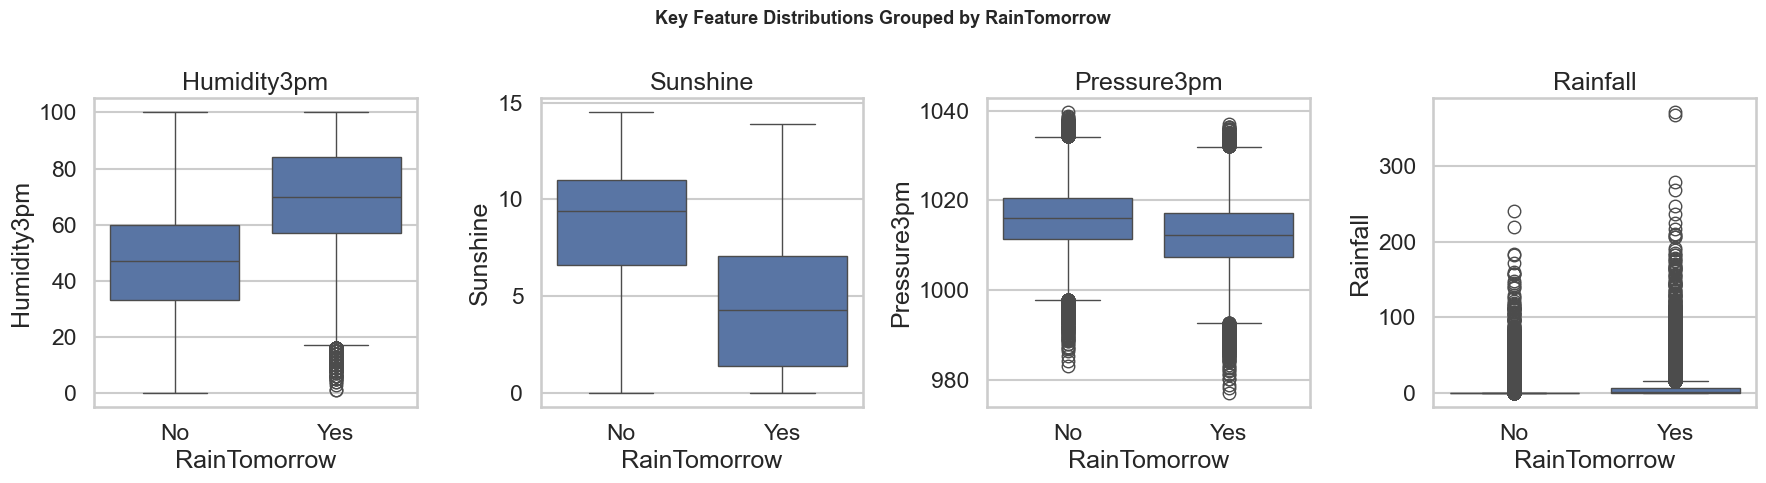

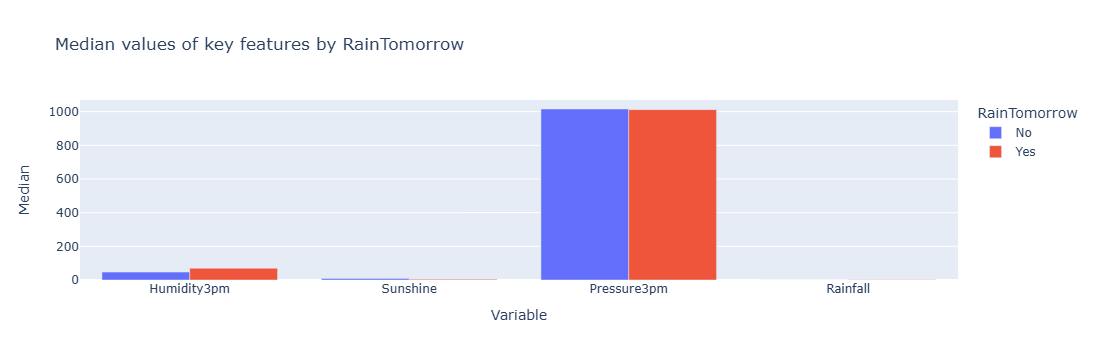

In [43]:
# Boxplots: key numerical features grouped by RainTomorrow


fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(data=df, x="RainTomorrow", y="Humidity3pm", ax=axes[0])
axes[0].set_title("Humidity3pm")

sns.boxplot(data=df, x="RainTomorrow", y="Sunshine", ax=axes[1])
axes[1].set_title("Sunshine")

sns.boxplot(data=df, x="RainTomorrow", y="Pressure3pm", ax=axes[2])
axes[2].set_title("Pressure3pm")

sns.boxplot(data=df, x="RainTomorrow", y="Rainfall", ax=axes[3])
axes[3].set_title("Rainfall")

plt.suptitle(
    "Key Feature Distributions Grouped by RainTomorrow",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "fig_14_boxplots_by_rain.png"), dpi=150, bbox_inches="tight")
plt.show()

# Interactive summary using median values
median_by_target = df.groupby("RainTomorrow")[["Humidity3pm", "Sunshine", "Pressure3pm", "Rainfall"]].median().reset_index()
median_long = median_by_target.melt(id_vars="RainTomorrow", var_name="Variable", value_name="Median")

fig = px.bar(
    median_long,
    x="Variable",
    y="Median",
    color="RainTomorrow",
    barmode="group",
    title="Median values of key features by RainTomorrow"
)
fig.show()


**Interpretation:** Humidity3pm, Cloud3pm, and Cloud9am show the clearest separation; rainy days have noticeably higher values. Sunshine and Pressure3pm show the opposite: rainy days have lower sunshine hours and slightly lower pressure. Rainfall (today) is also higher on days followed by rain, confirming wet-weather persistence. WindGustSpeed shows moderate separation. These patterns are fully consistent with the correlation analysis in section 11.2.

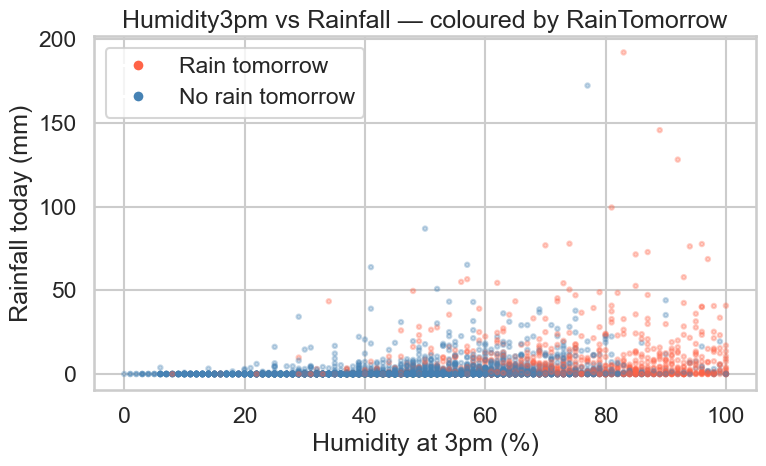

In [44]:
# Scatter: Humidity3pm vs Rainfall
sample = df[['Humidity3pm', 'Rainfall', 'RainTomorrow']].dropna().sample(5000, random_state=42)

colors = sample['RainTomorrow'].map({'No': 'steelblue', 'Yes': 'tomato'})
plt.figure(figsize=(8, 5))
plt.scatter(sample['Humidity3pm'], sample['Rainfall'],
            c=colors, alpha=0.3, s=10)
plt.xlabel('Humidity at 3pm (%)')
plt.ylabel('Rainfall today (mm)')
plt.title('Humidity3pm vs Rainfall — coloured by RainTomorrow')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
                           markersize=8, label='Rain tomorrow'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                           markersize=8, label='No rain tomorrow')]
plt.legend(handles=legend_elements)
plt.tight_layout()

plt.savefig(os.path.join(CHARTS_DIR, "fig_25_scatter_humidity_rainfall.png"), dpi=150, bbox_inches="tight")
plt.show()


## 19. Statistical Analysis

This audit section backs up the visual patterns with formal tests. The goal is to leave Notebook 1 with evidence-based conclusions that can justify the feature engineering and modeling choices in the next notebooks.

In [45]:
from scipy.stats import pearsonr, spearmanr

# Pearson + Spearman with p-values
corr_test_results = []

for col in numeric_cols:
    temp = df[[col, "RainTomorrow_num"]].dropna()

    pearson_r, pearson_p = pearsonr(temp[col], temp["RainTomorrow_num"])
    spearman_r, spearman_p = spearmanr(temp[col], temp["RainTomorrow_num"])

    corr_test_results.append({
        "Variable": col,
        "Pearson_r": round(pearson_r, 3),
        "Pearson_p": round(pearson_p, 6),
        "Spearman_r": round(spearman_r, 3),
        "Spearman_p": round(spearman_p, 6)
    })

corr_test_report = pd.DataFrame(corr_test_results).sort_values("Pearson_r", ascending=False)

print("Pearson and Spearman tests:")
print(corr_test_report.to_string(index=False))


Pearson and Spearman tests:
     Variable  Pearson_r  Pearson_p  Spearman_r  Spearman_p
  Humidity3pm      0.446        0.0       0.431         0.0
     Cloud3pm      0.382        0.0       0.394         0.0
     Cloud9am      0.317        0.0       0.325         0.0
  Humidity9am      0.257        0.0       0.267         0.0
     Rainfall      0.239        0.0       0.332         0.0
WindGustSpeed      0.234        0.0       0.212         0.0
 WindSpeed9am      0.091        0.0       0.081         0.0
 WindSpeed3pm      0.088        0.0       0.076         0.0
      MinTemp      0.084        0.0       0.076         0.0
      Temp9am     -0.026        0.0      -0.030         0.0
  Evaporation     -0.119        0.0      -0.138         0.0
      MaxTemp     -0.159        0.0      -0.159         0.0
      Temp3pm     -0.192        0.0      -0.193         0.0
  Pressure3pm     -0.226        0.0      -0.215         0.0
  Pressure9am     -0.246        0.0      -0.236         0.0
     Sunshin

In [46]:
from scipy.stats import f_oneway

# ANOVA: compare the mean of each numerical variable for RainTomorrow = Yes vs No
anova_results = []

for col in numeric_cols:
    no_group = df.loc[df["RainTomorrow"] == "No", col].dropna()
    yes_group = df.loc[df["RainTomorrow"] == "Yes", col].dropna()

    if len(no_group) > 1 and len(yes_group) > 1:
        f_stat, p_value = f_oneway(no_group, yes_group)

        anova_results.append({
            "Variable": col,
            "F_statistic": round(f_stat, 3),
            "p_value": round(p_value, 6)
        })

anova_report = pd.DataFrame(anova_results).sort_values("p_value")

print("ANOVA results:")
print(anova_report.to_string(index=False))


ANOVA results:
     Variable  F_statistic  p_value
      MinTemp     1004.355      0.0
      MaxTemp     3690.862      0.0
     Rainfall     8531.370      0.0
  Evaporation     1174.195      0.0
     Sunshine    18966.163      0.0
WindGustSpeed     7700.512      0.0
 WindSpeed9am     1175.920      0.0
 WindSpeed3pm     1084.645      0.0
  Humidity9am     9943.628      0.0
  Humidity3pm    34441.750      0.0
  Pressure9am     8282.947      0.0
  Pressure3pm     6902.930      0.0
     Cloud9am     9916.961      0.0
     Cloud3pm    14527.785      0.0
      Temp9am       93.314      0.0
      Temp3pm     5362.533      0.0


In [47]:
from scipy.stats import chi2_contingency

# Chi-square test for categorical variables vs RainTomorrow
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["Date", "RainTomorrow"]]

chi2_results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df["RainTomorrow"])

    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(table)

        chi2_results.append({
            "Variable": col,
            "Chi2_statistic": round(chi2, 3),
            "p_value": round(p_value, 6),
            "Degrees_of_freedom": dof
        })

chi2_report = pd.DataFrame(chi2_results).sort_values("p_value")

print("Chi-square results:")
print(chi2_report.to_string(index=False))


Chi-square results:
   Variable  Chi2_statistic  p_value  Degrees_of_freedom
   Location        3544.790      0.0                  48
WindGustDir        1519.901      0.0                  15
 WindDir9am        2214.847      0.0                  15
 WindDir3pm        1281.267      0.0                  15
  RainToday       13799.480      0.0                   1


**Interpretation of statistical tests**

**Pearson and Spearman correlation (numerical features vs RainTomorrow):**

- `Sunshine` and `Humidity3pm` are the two strongest predictors: Sunshine with a strong negative correlation (sunny days rarely precede rain) and Humidity3pm with a strong positive correlation (humid afternoons often precede rain)
- `Cloud3pm`, `Cloud9am`, `Pressure3pm`, and `Rainfall` all show meaningful correlations in the expected directions
- Where Spearman_r is notably larger than Pearson_r (as with `Rainfall`) the relationship is real but non-linear. This means tree-based models will capture it better than Logistic Regression
- All reported correlations have p-values of 0.000000, meaning every result is statistically significant at p < 0.0001. With 140,000+ observations, even a weak correlation is significant, so the **r-value** matters more than the p-value here.

**ANOVA:**

The ANOVA table shows F-statistics and p-values for each numerical feature. All p-values are 0.000000 and every tested feature has a significantly different mean between rainy and dry days. However, the F-statistic tells us how strongly each feature separates the two groups:
- Features with the highest F-statistics (Sunshine, Humidity3pm, Cloud3pm, Pressure3pm) show the largest group separation consistent with what the boxplots in Section 15 showed visually.
- Features with lower F-statistics (MaxTemp, Temp3pm) are significant but less discriminating and they differ between groups but the overlap is larger.

**Chi-square (categorical features vs RainTomorrow):**

All categorical features produce p-values of 0.000000 and none of them are independent of RainTomorrow. The chi-square statistic tells us the strength of association:
- `RainToday` produces by far the largest chi-square statistic, confirming it is the strongest categorical predictor, knowing it rained today substantially raises tomorrow's rain probability
- `Location`, `WindGustDir`, `WindDir3pm`, `WindDir9am` are all significantly associated, confirming that both geographic position and wind direction carry information about tomorrow's rain

In conclusion, every feature we plan to keep in the next step is confirmed statistically significant here. The ranking of features by F-statistic and correlation strength is consistent with the visual analysis in Sections 14 and 15, and the statistical tests confirm what the charts showed, they do not contradict them.